In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, confusion_matrix, roc_auc_score, auc, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import optuna

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

In [25]:
train_df = pd.read_csv('../data/train.csv').drop(columns = 'CustomerID').dropna()
test_df = pd.read_csv('../data/test.csv').drop(columns = 'CustomerID')
train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  str    
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  str    
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), str(3)
memory usage: 40.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374

In [26]:
print(train_df.isna().sum())
print(test_df.isna().sum())

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [27]:
print(train_df.duplicated().sum())
print(test_df.duplicated().sum())

0
0


In [29]:
train_df[['Age','Usage Frequency', 'Support Calls', 'Payment Delay', 'Last Interaction', 'Churn']] = train_df[['Age','Usage Frequency', 'Support Calls', 'Payment Delay', 'Last Interaction', 'Churn']].astype(int)
test_df[['Tenure', 'Total Spend']] = test_df[['Tenure', 'Total Spend']].astype(float)

train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  int64  
 1   Gender             440832 non-null  str    
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  int64  
 4   Support Calls      440832 non-null  int64  
 5   Payment Delay      440832 non-null  int64  
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  str    
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  int64  
 10  Churn              440832 non-null  int64  
dtypes: float64(2), int64(6), str(3)
memory usage: 40.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age       

In [31]:
df = pd.concat([train_df, test_df], axis = 0)
df.info()

<class 'pandas.DataFrame'>
Index: 505206 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                505206 non-null  int64  
 1   Gender             505206 non-null  str    
 2   Tenure             505206 non-null  float64
 3   Usage Frequency    505206 non-null  int64  
 4   Support Calls      505206 non-null  int64  
 5   Payment Delay      505206 non-null  int64  
 6   Subscription Type  505206 non-null  str    
 7   Contract Length    505206 non-null  str    
 8   Total Spend        505206 non-null  float64
 9   Last Interaction   505206 non-null  int64  
 10  Churn              505206 non-null  int64  
dtypes: float64(2), int64(6), str(3)
memory usage: 46.3 MB


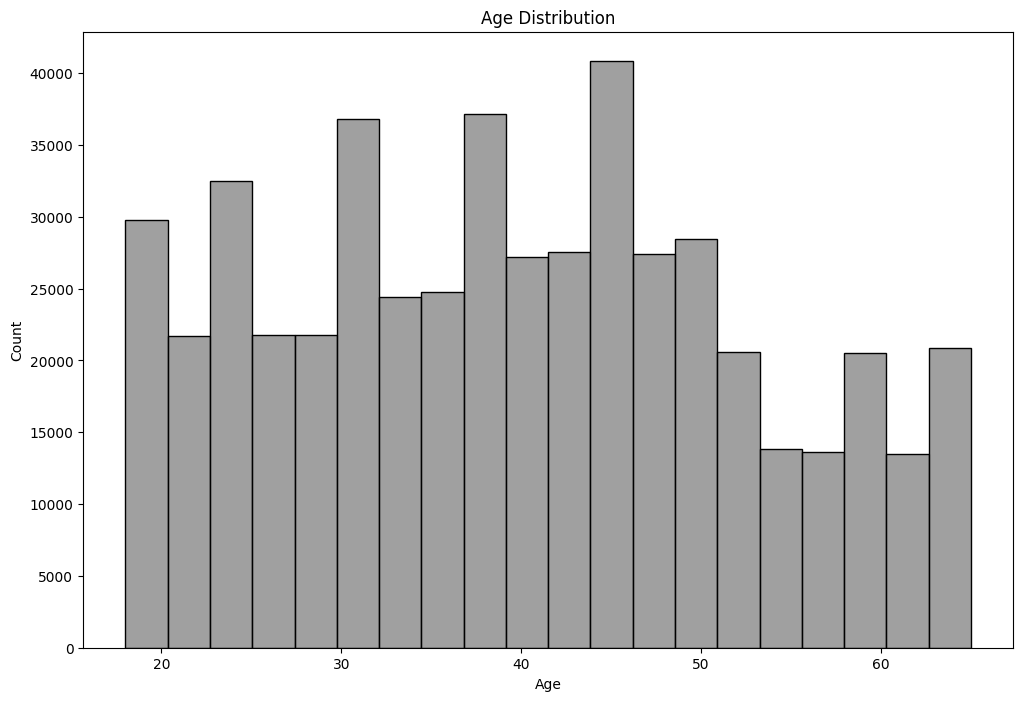

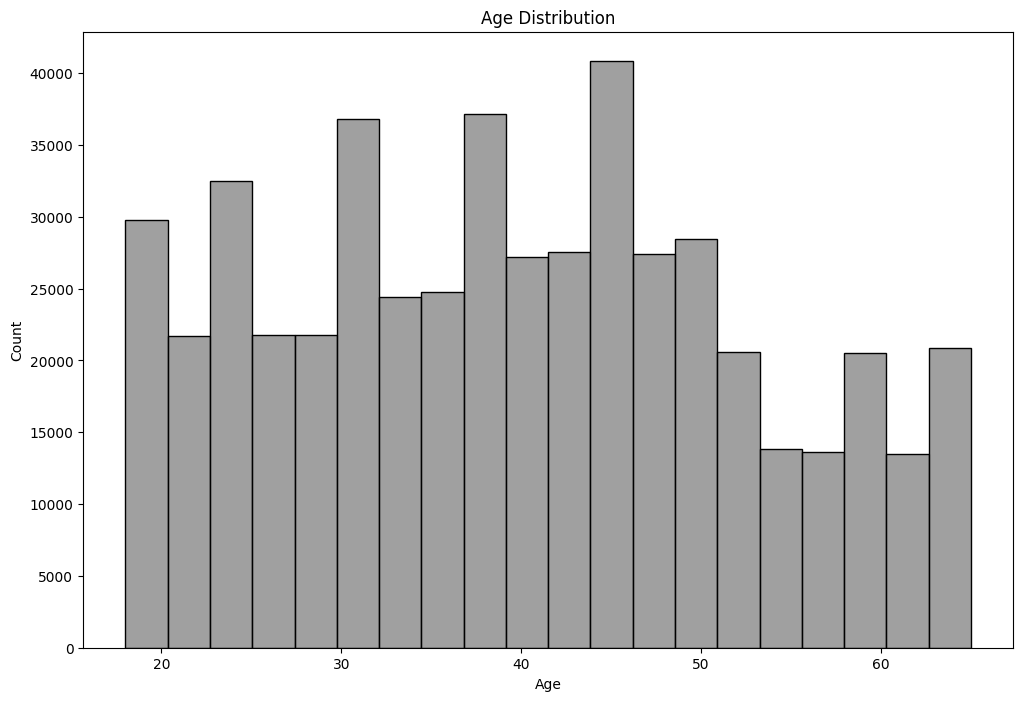

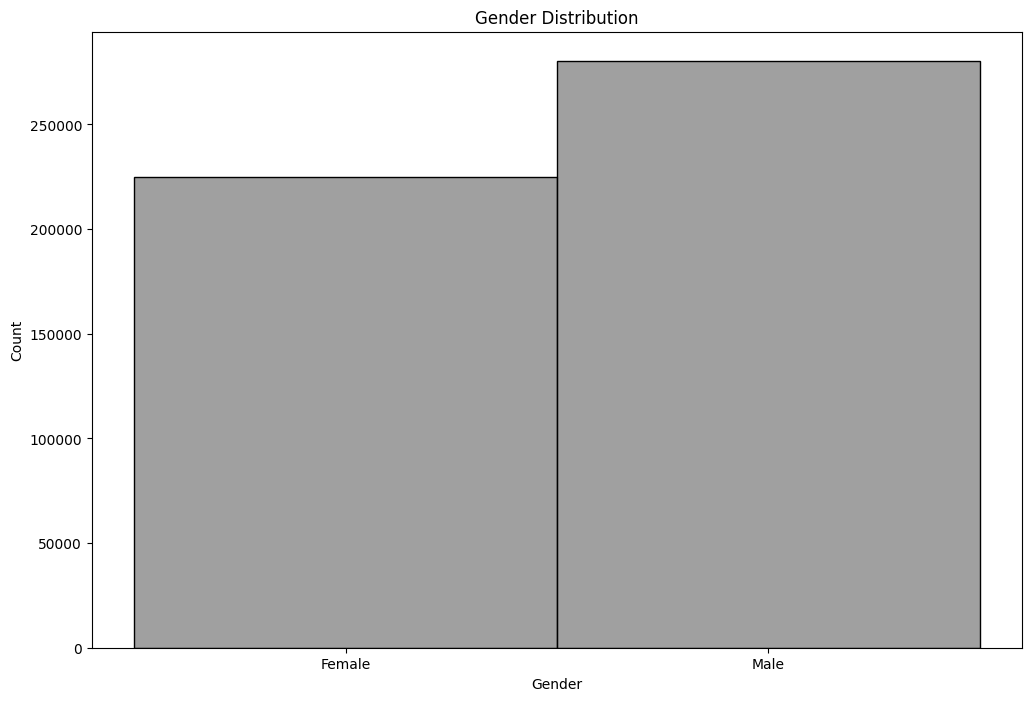

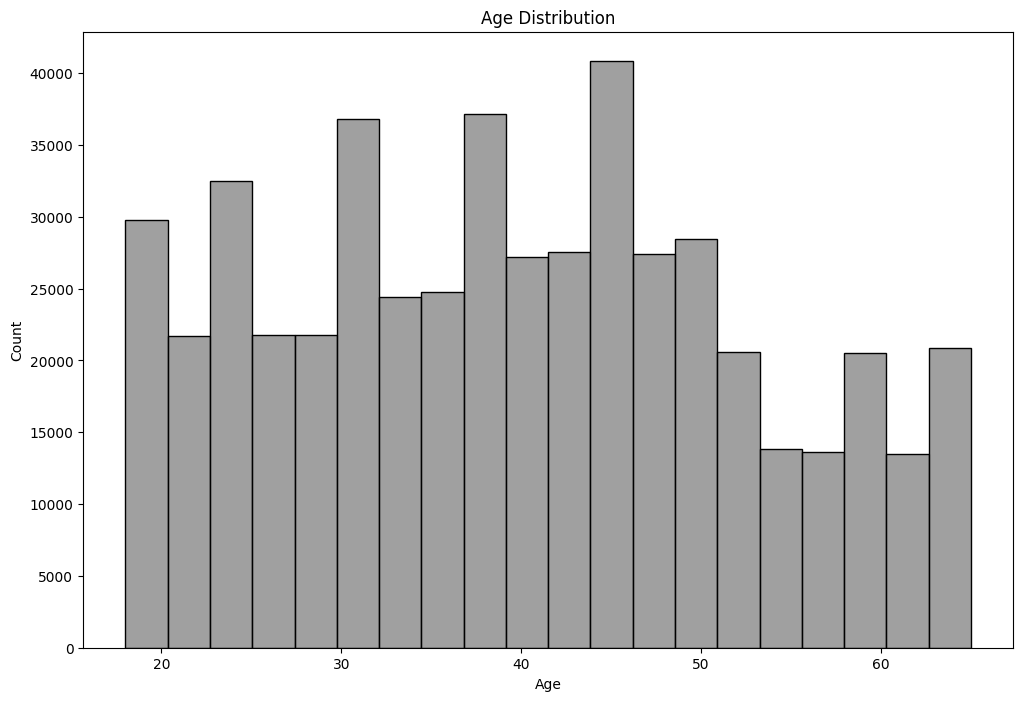

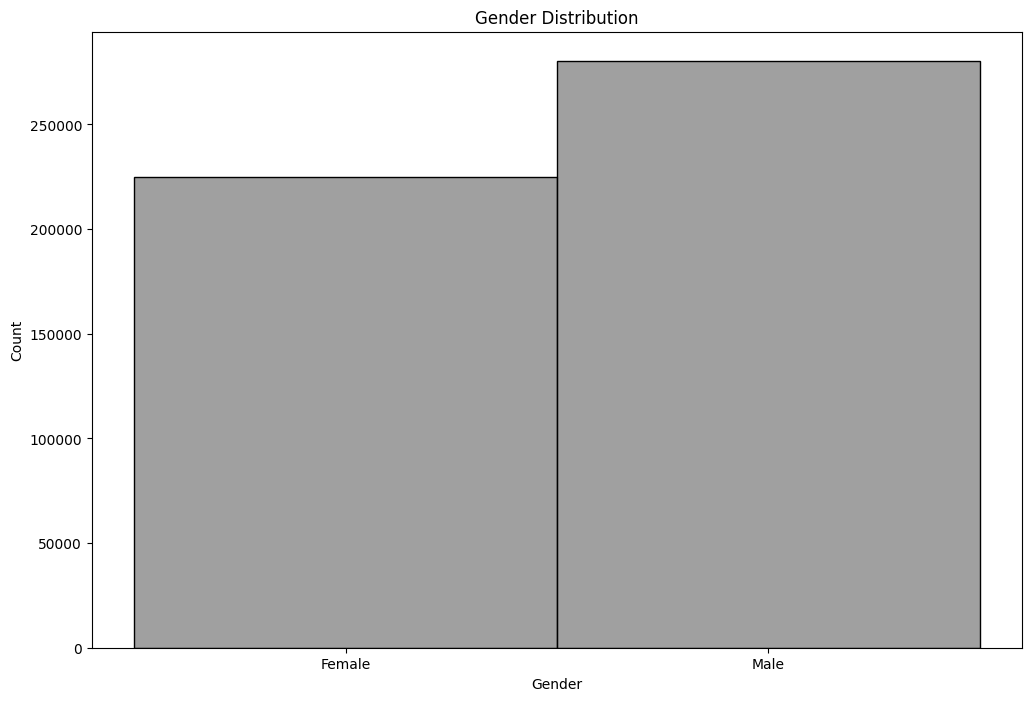

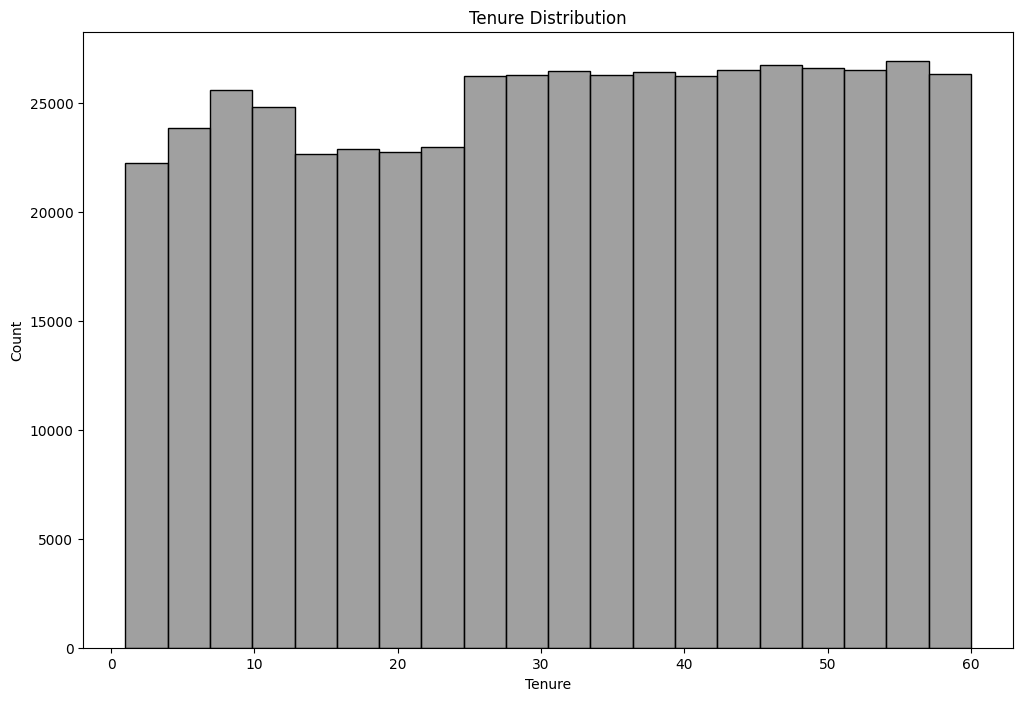

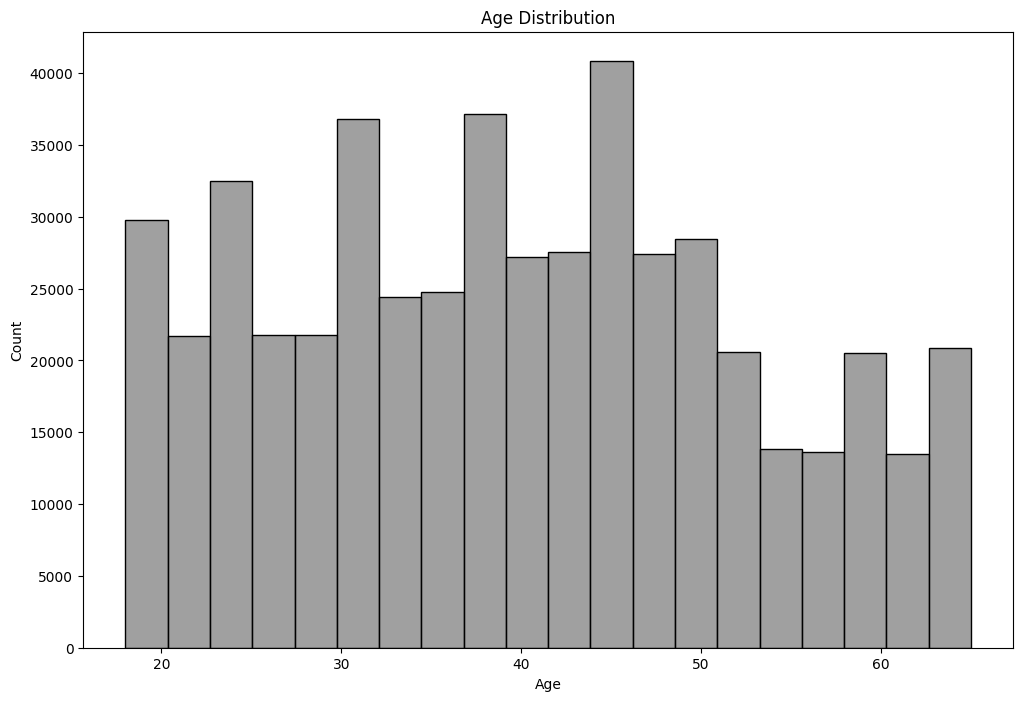

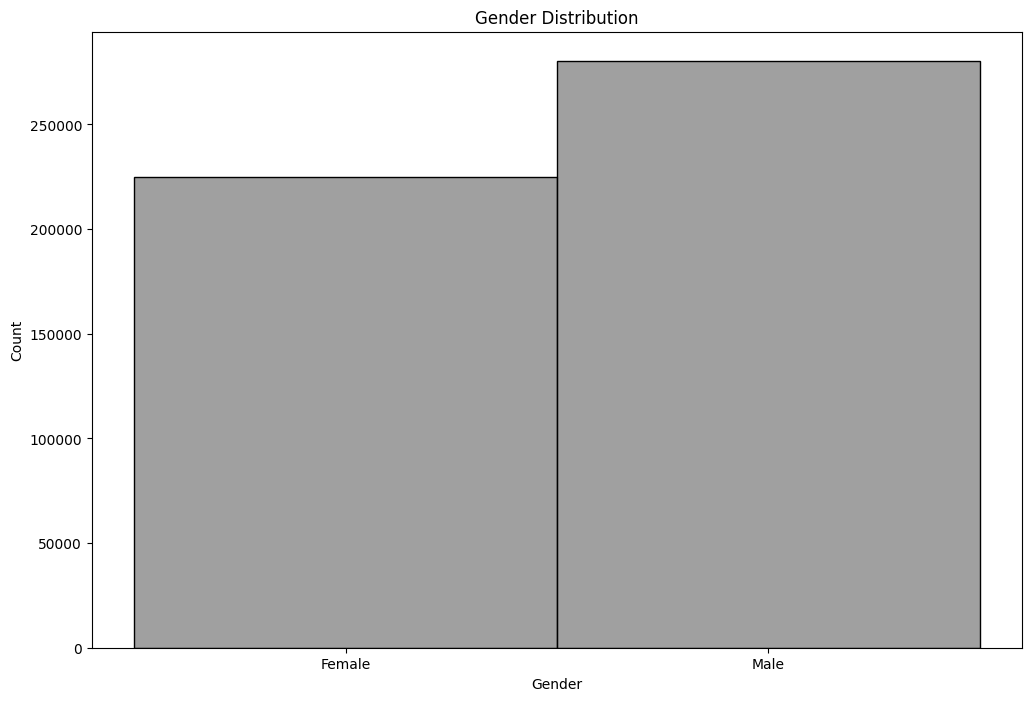

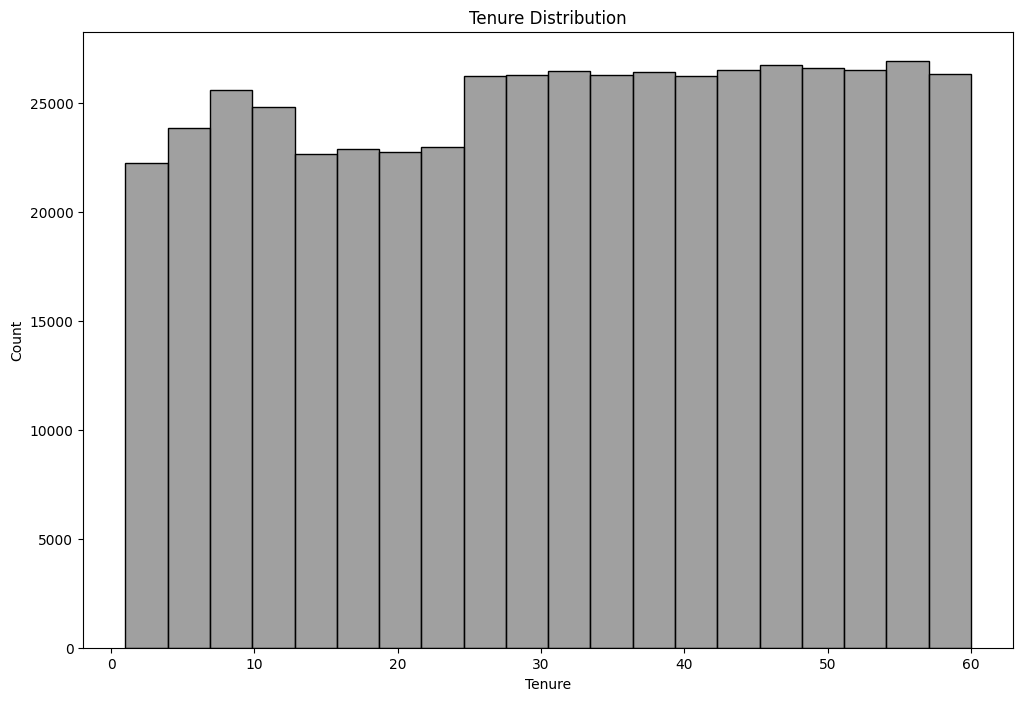

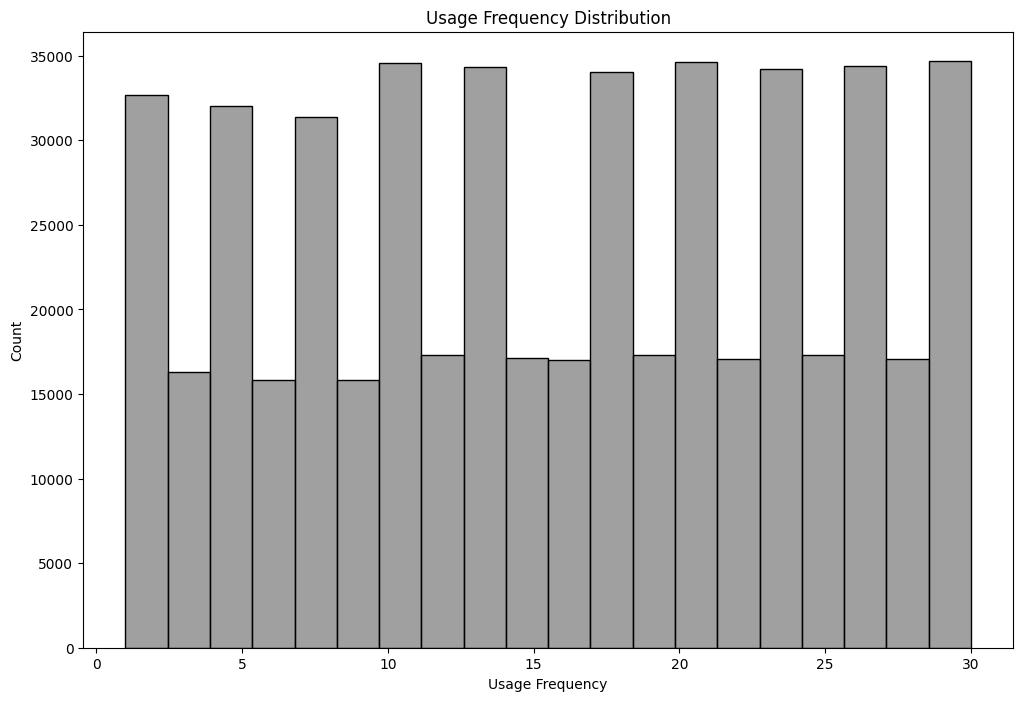

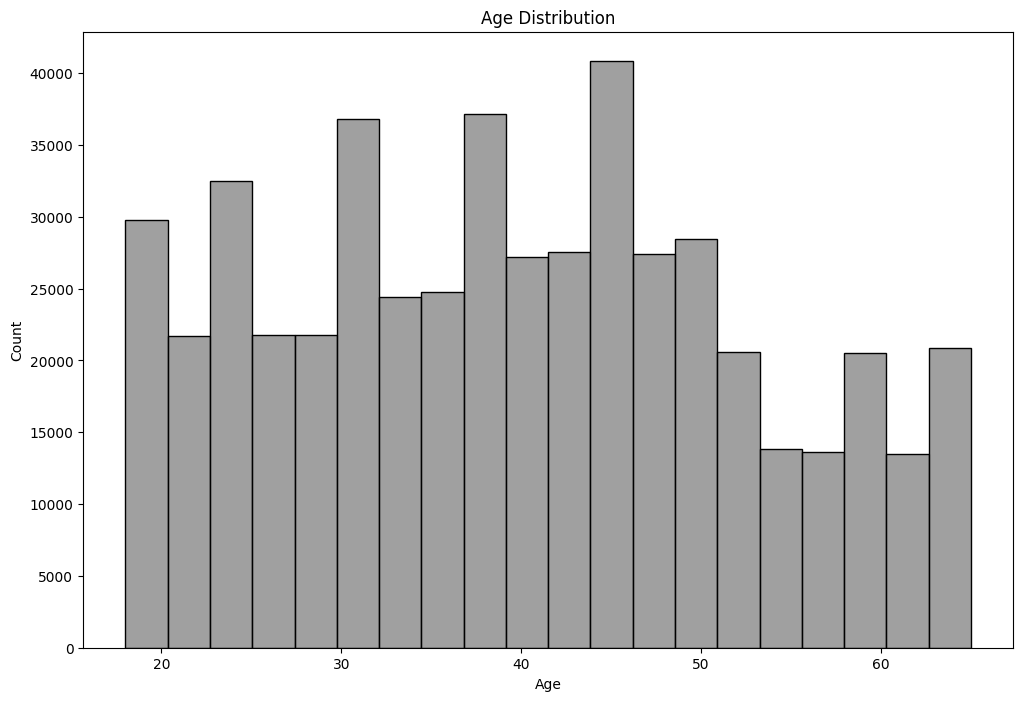

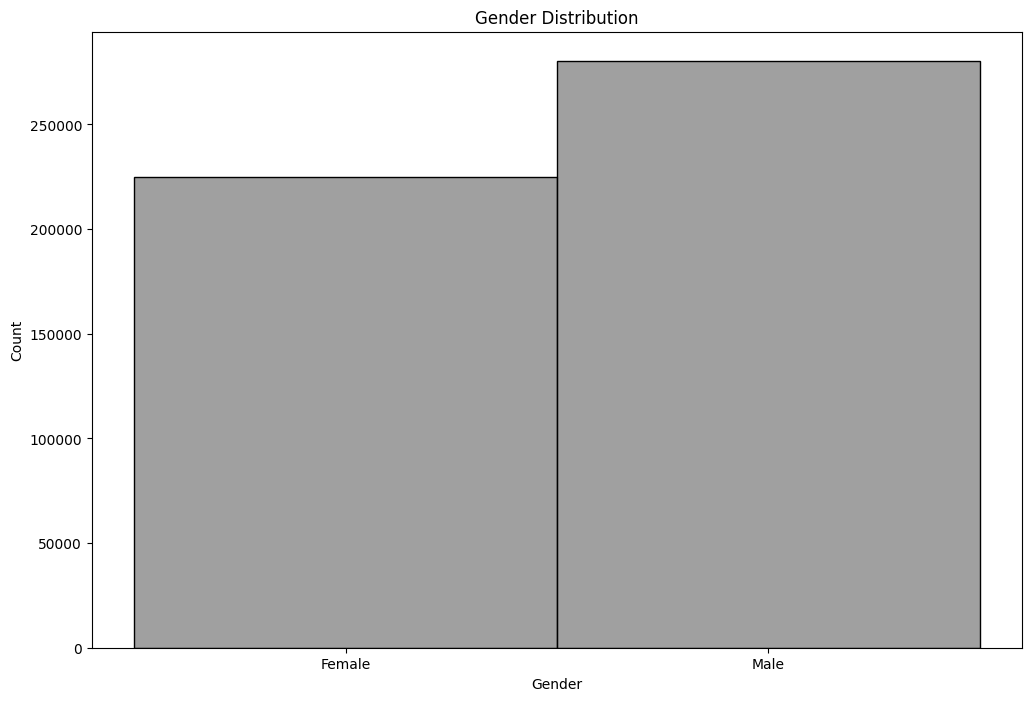

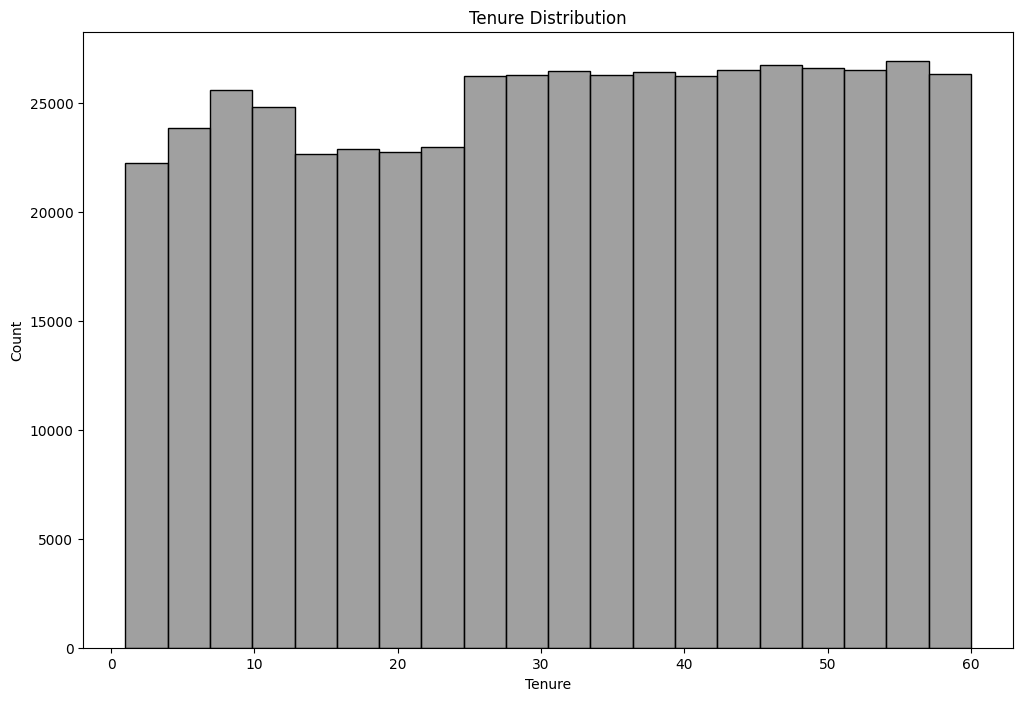

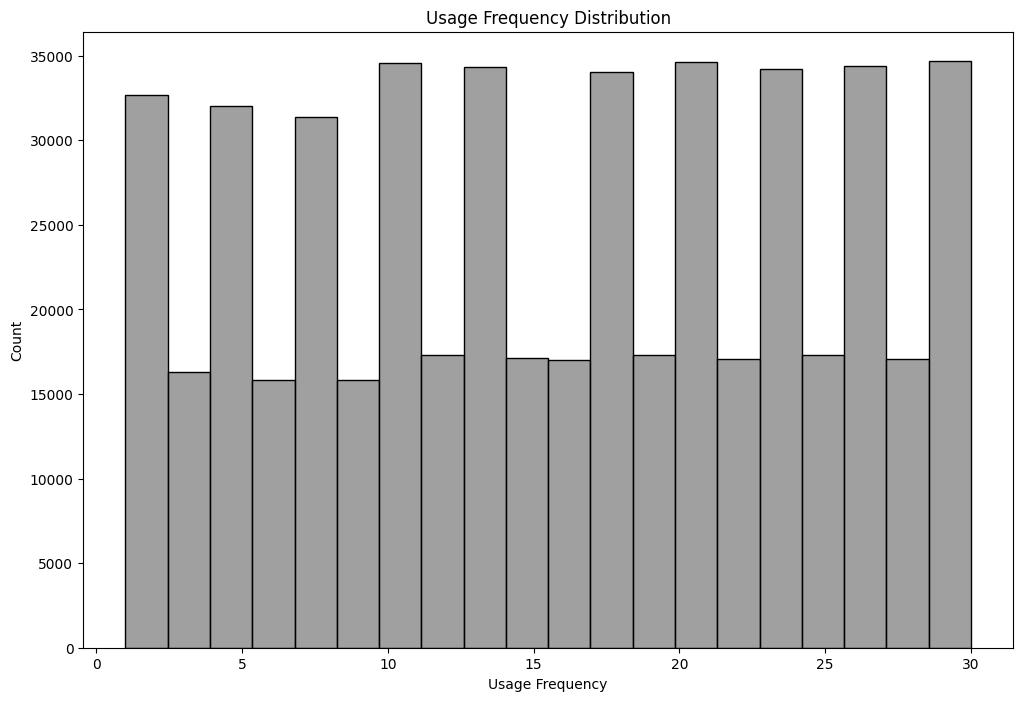

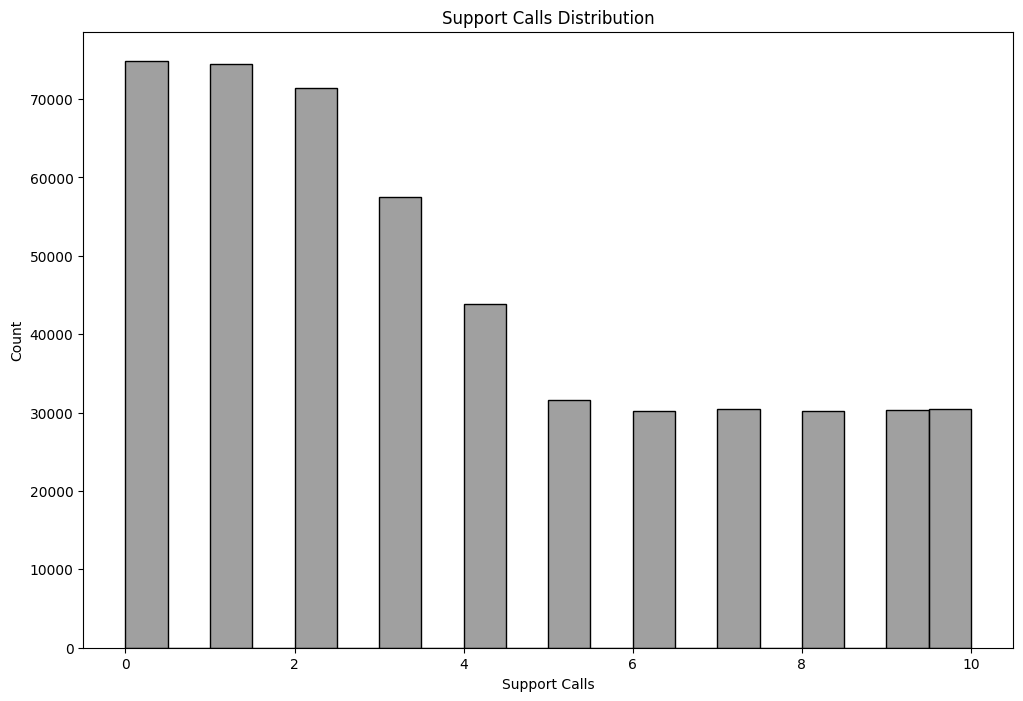

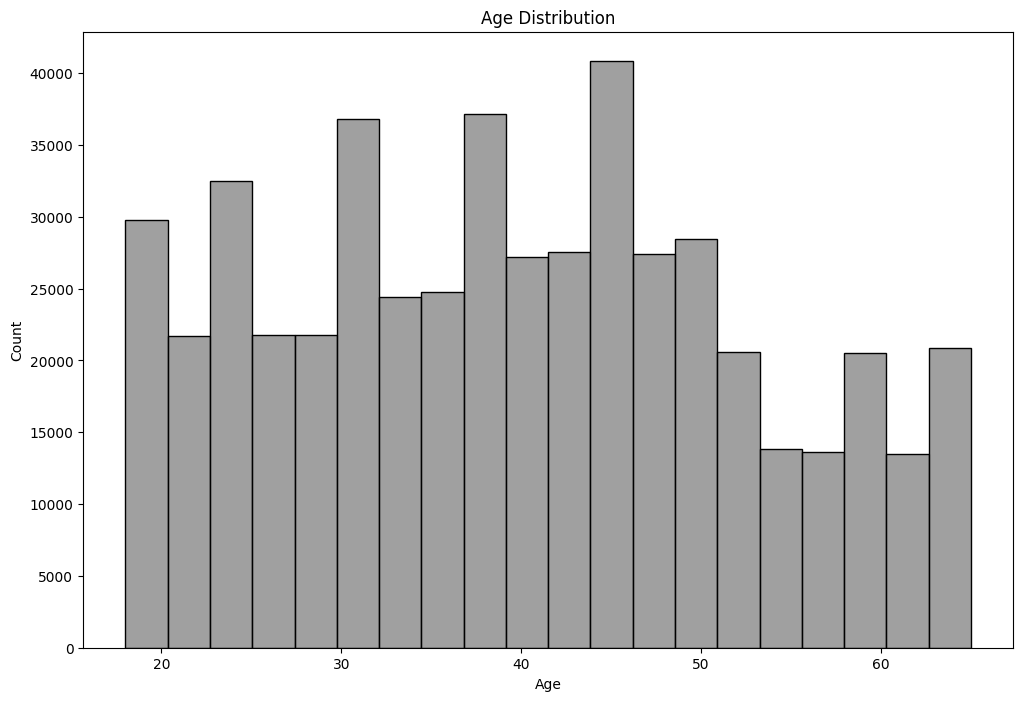

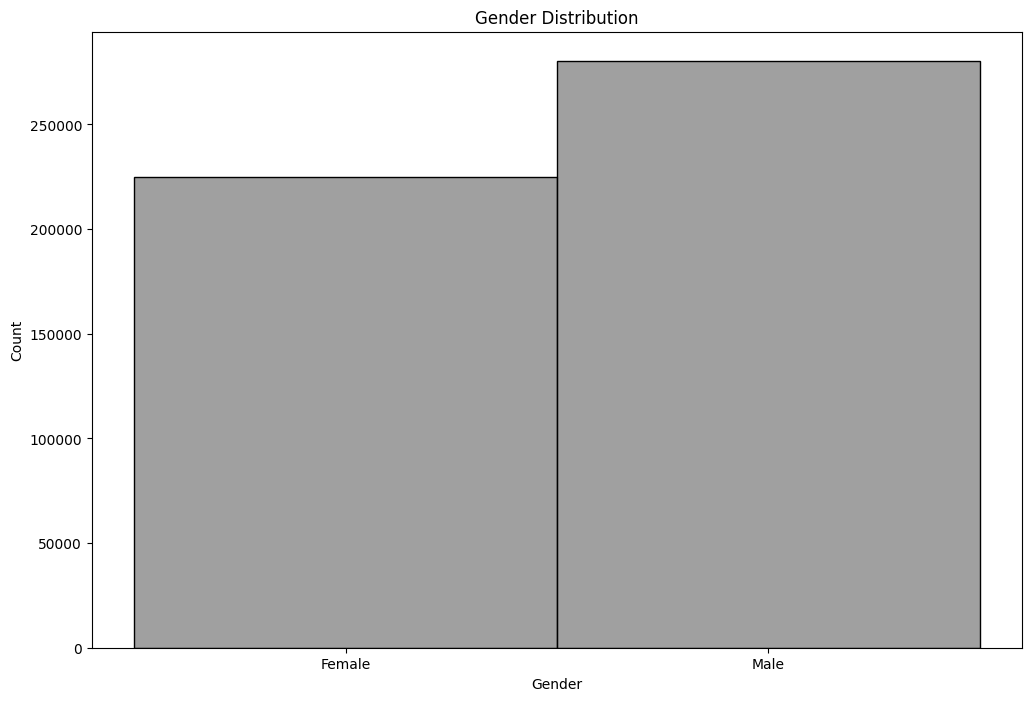

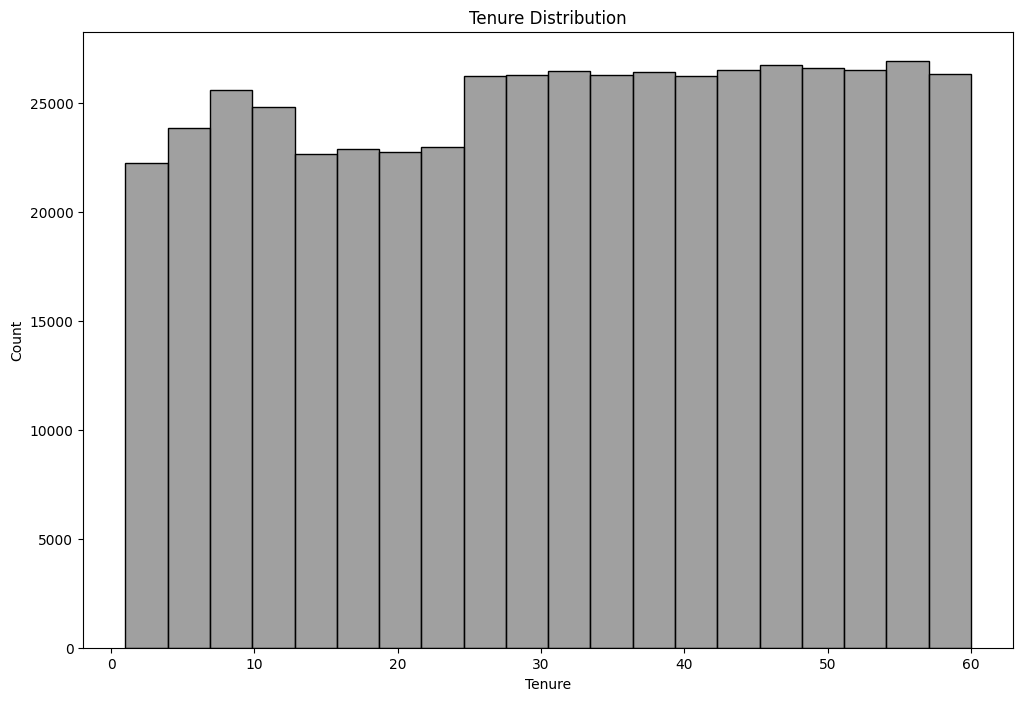

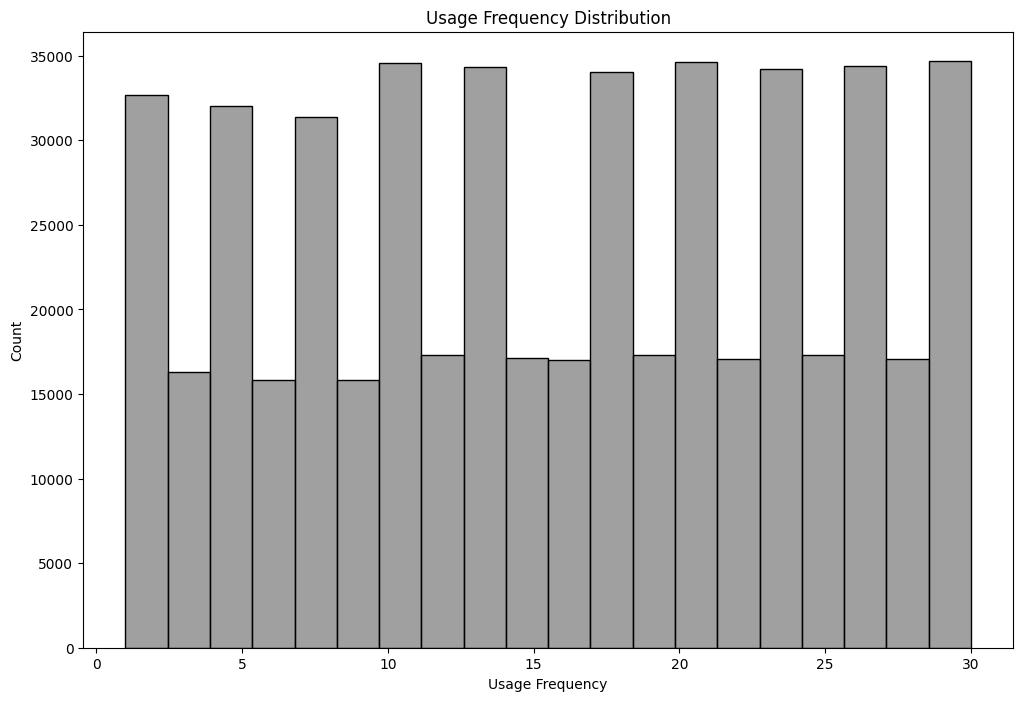

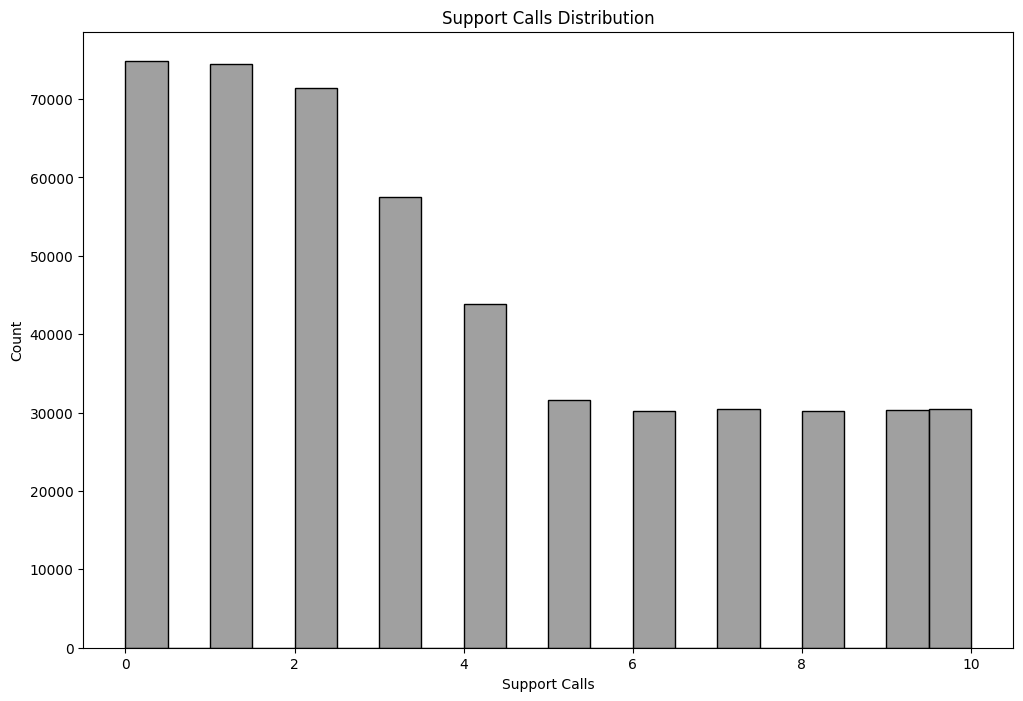

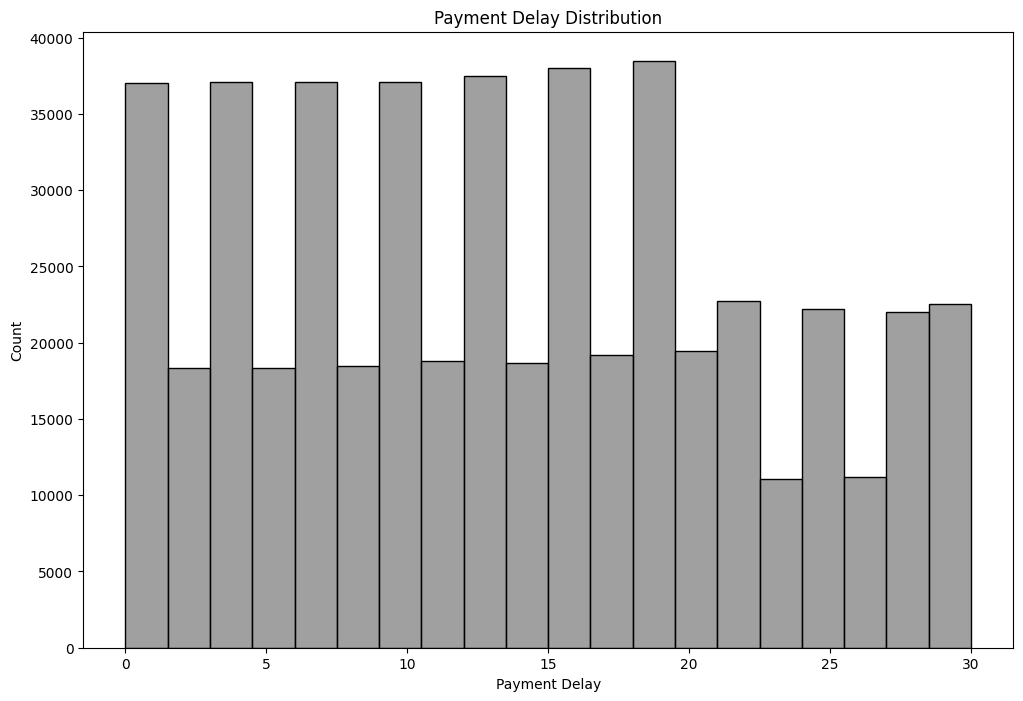

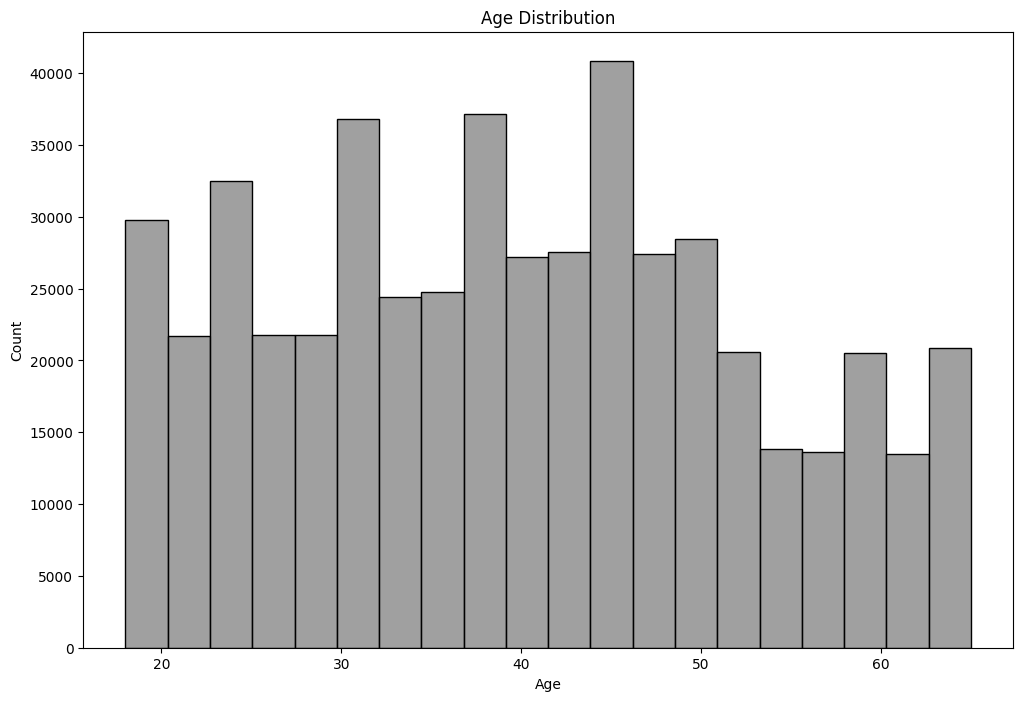

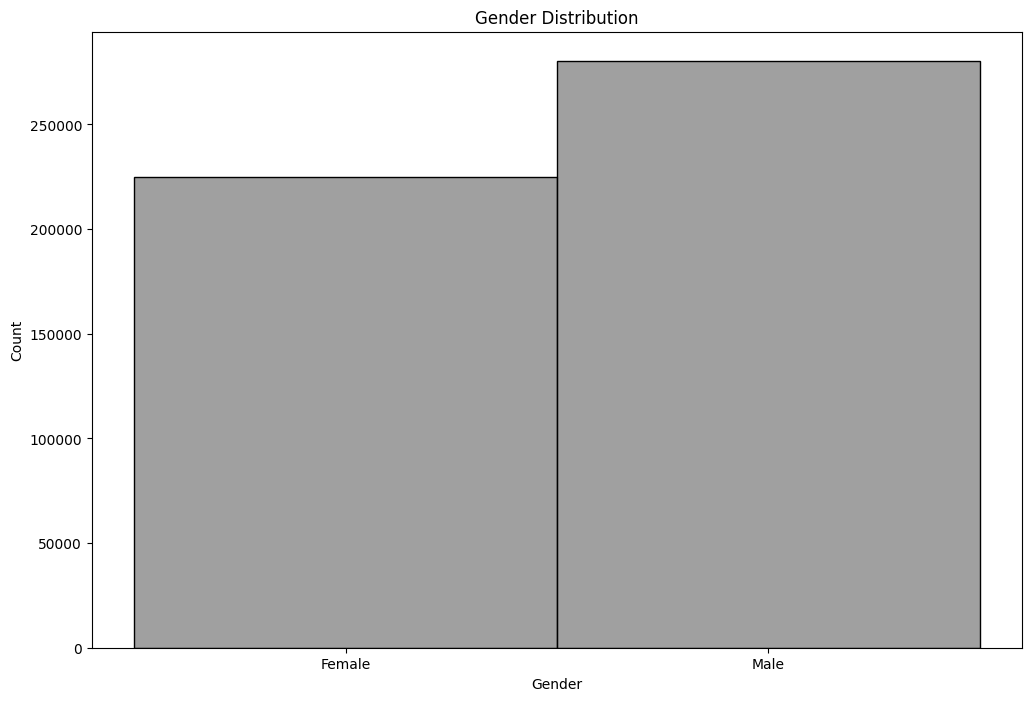

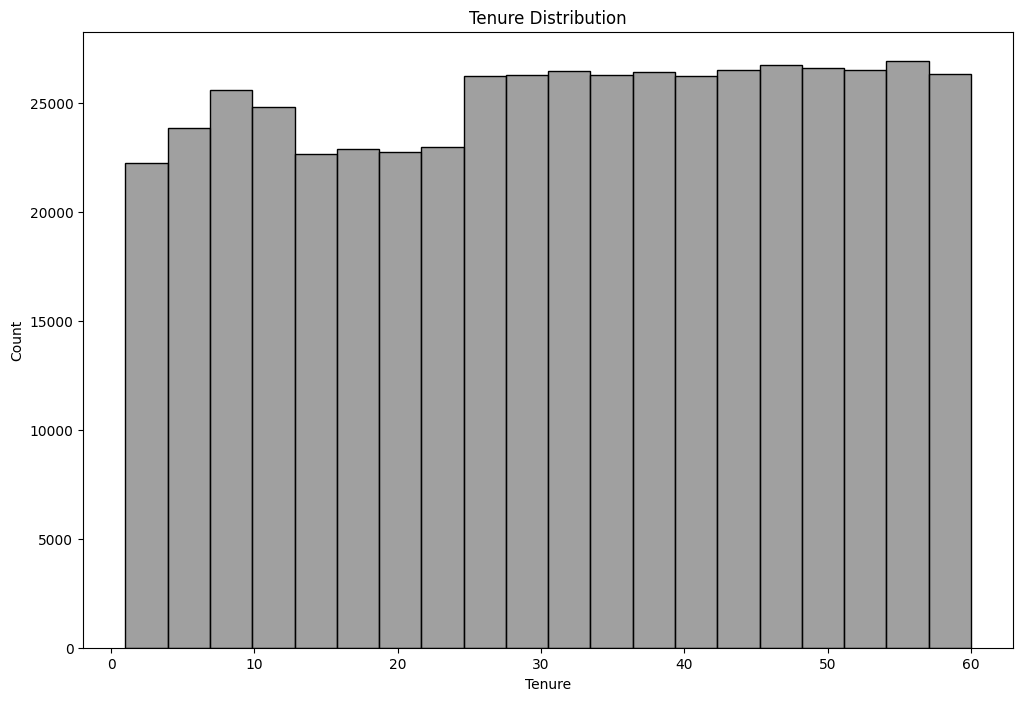

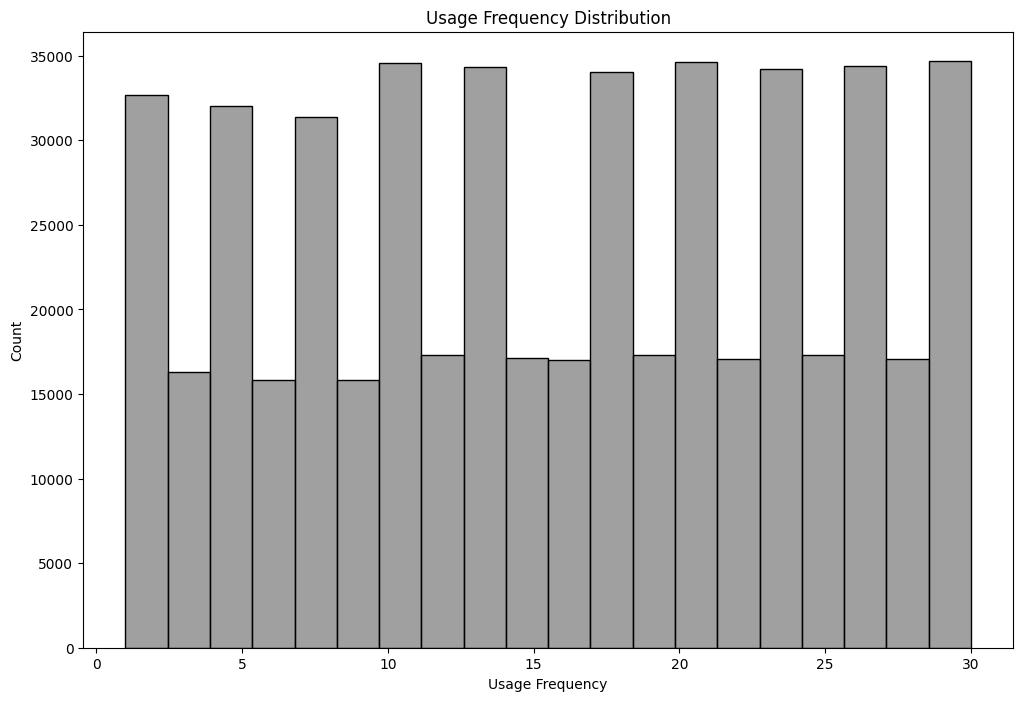

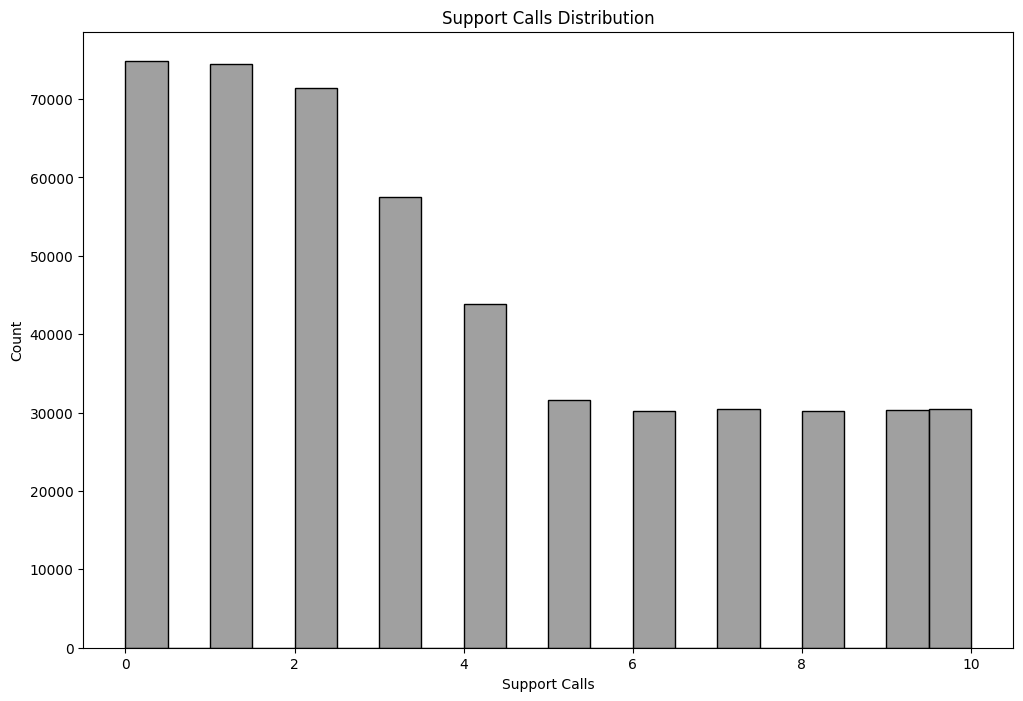

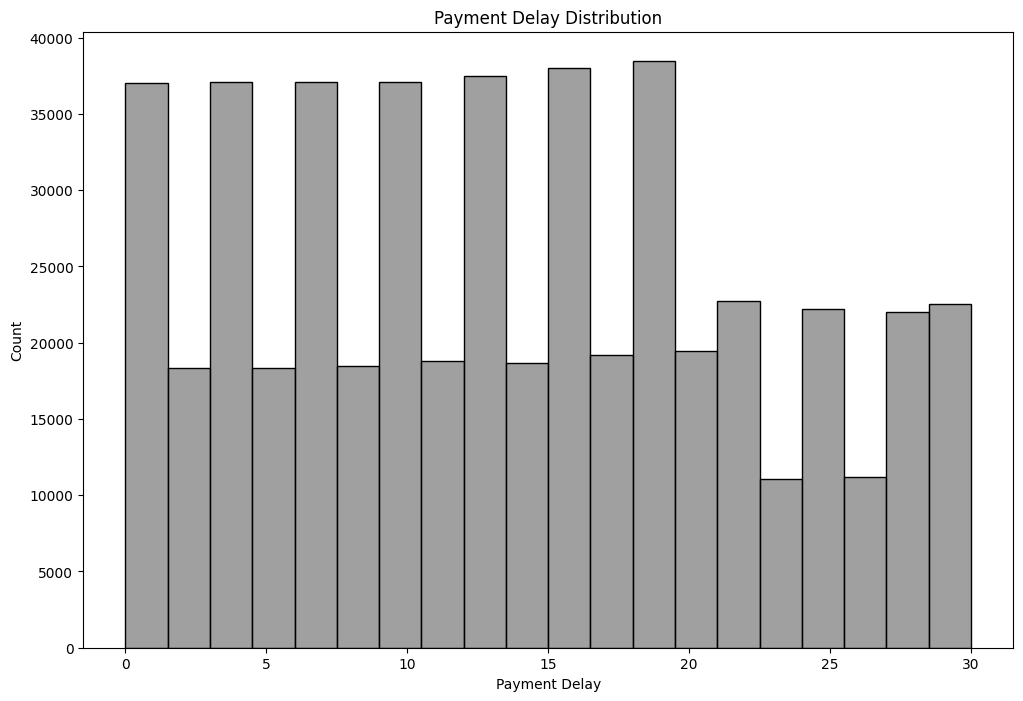

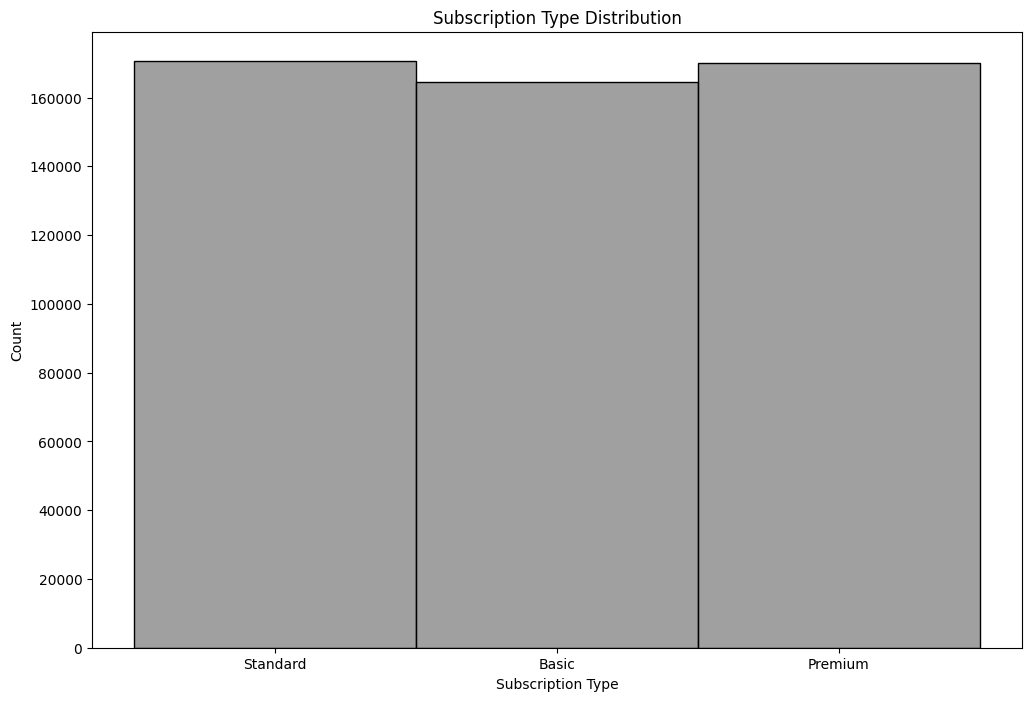

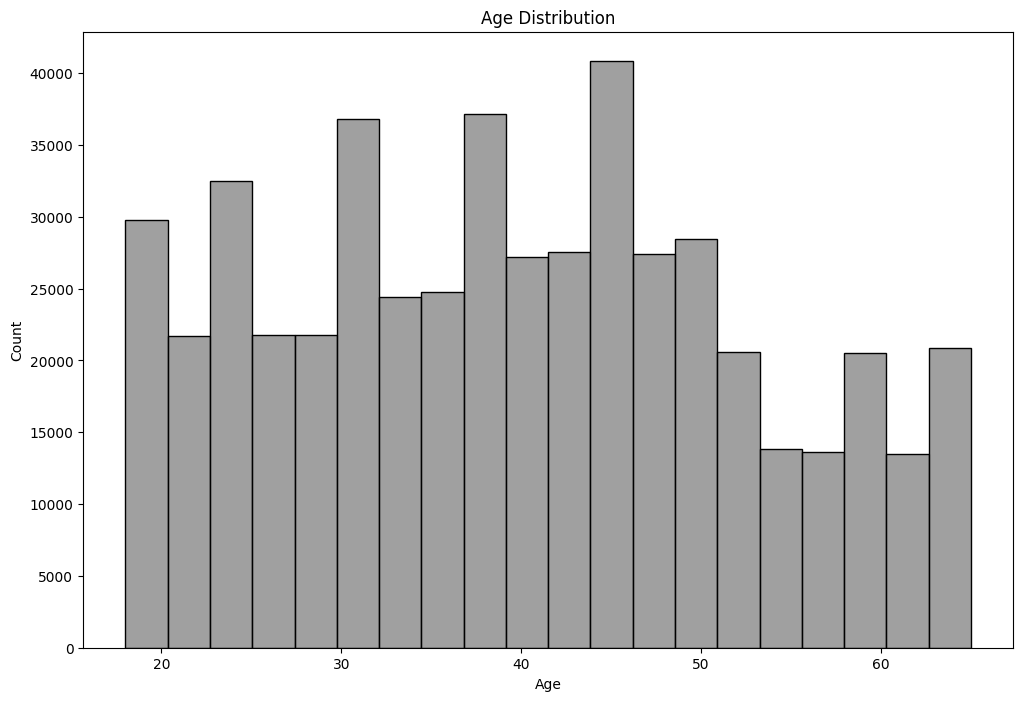

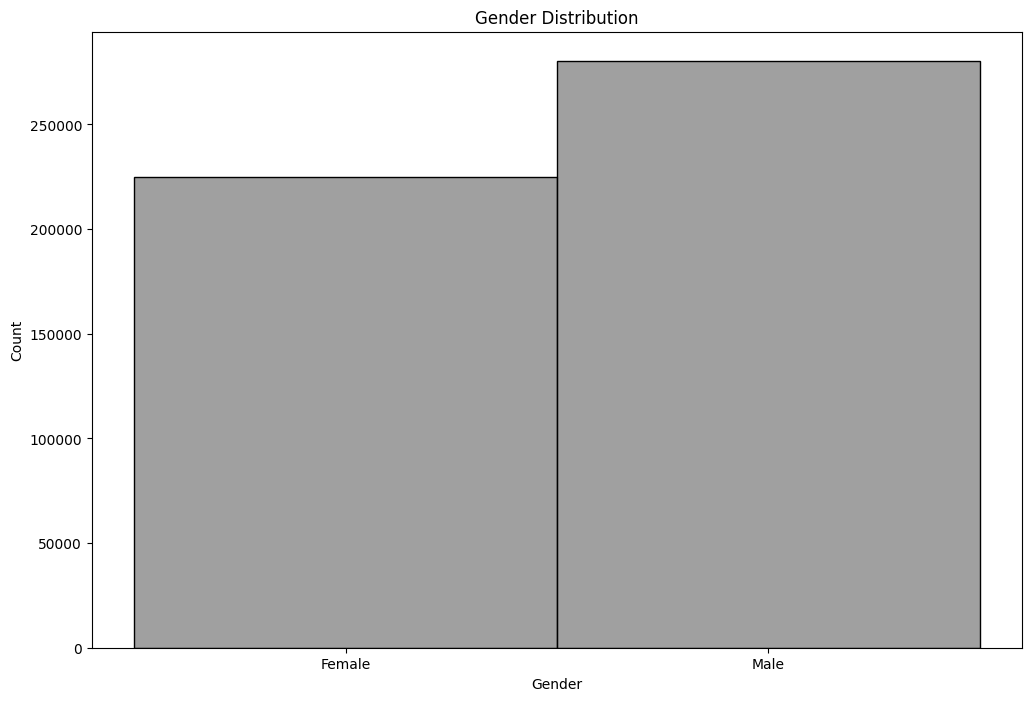

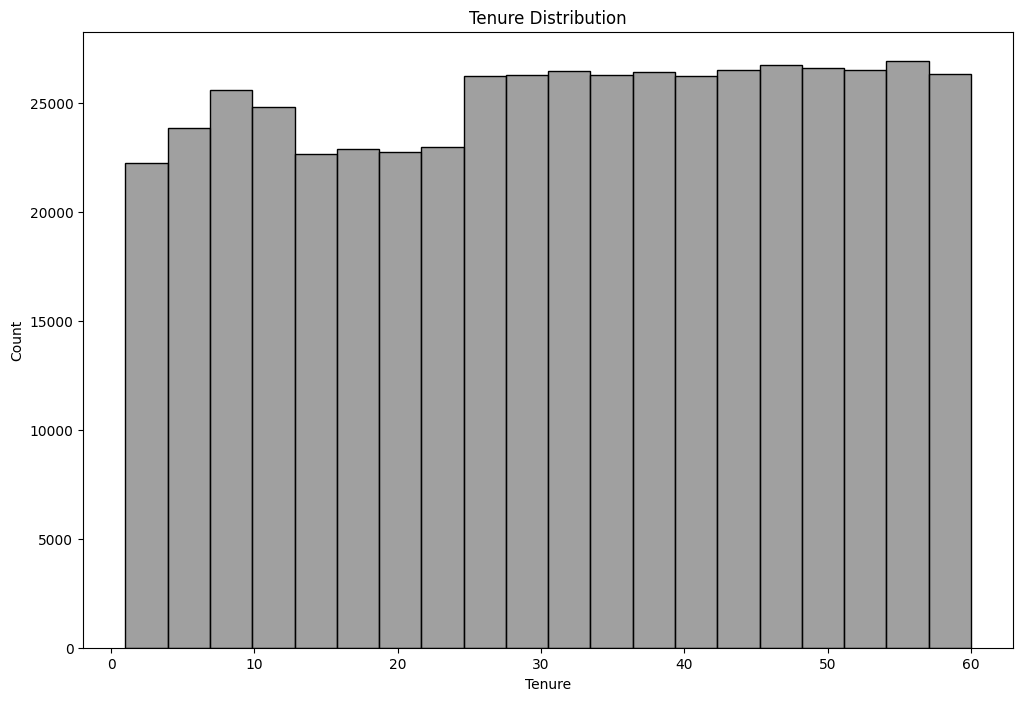

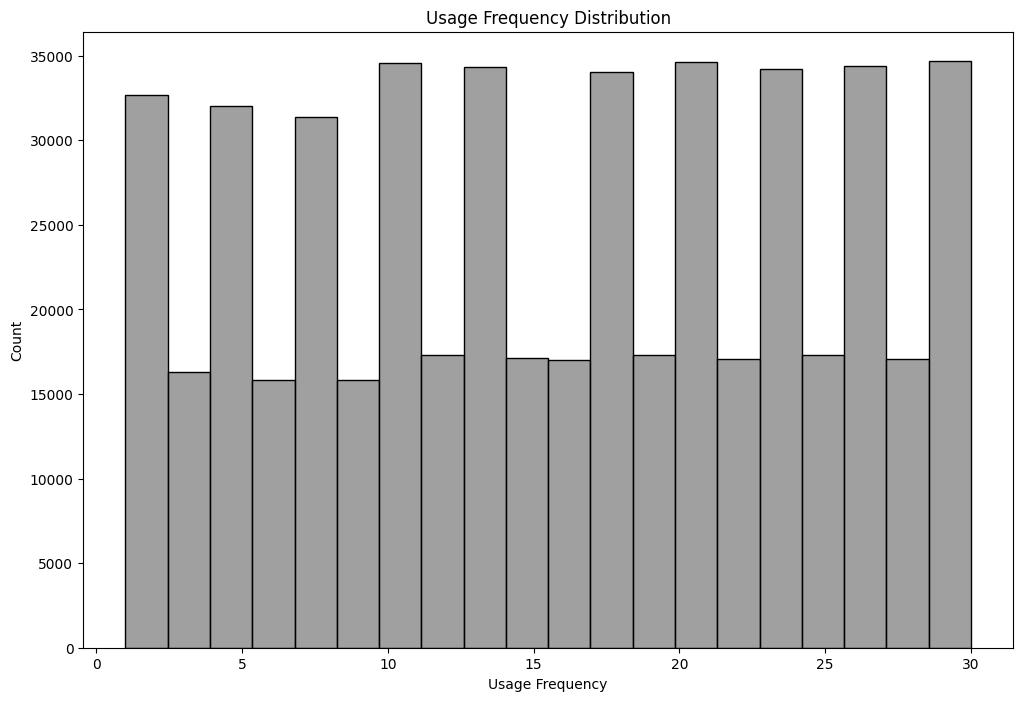

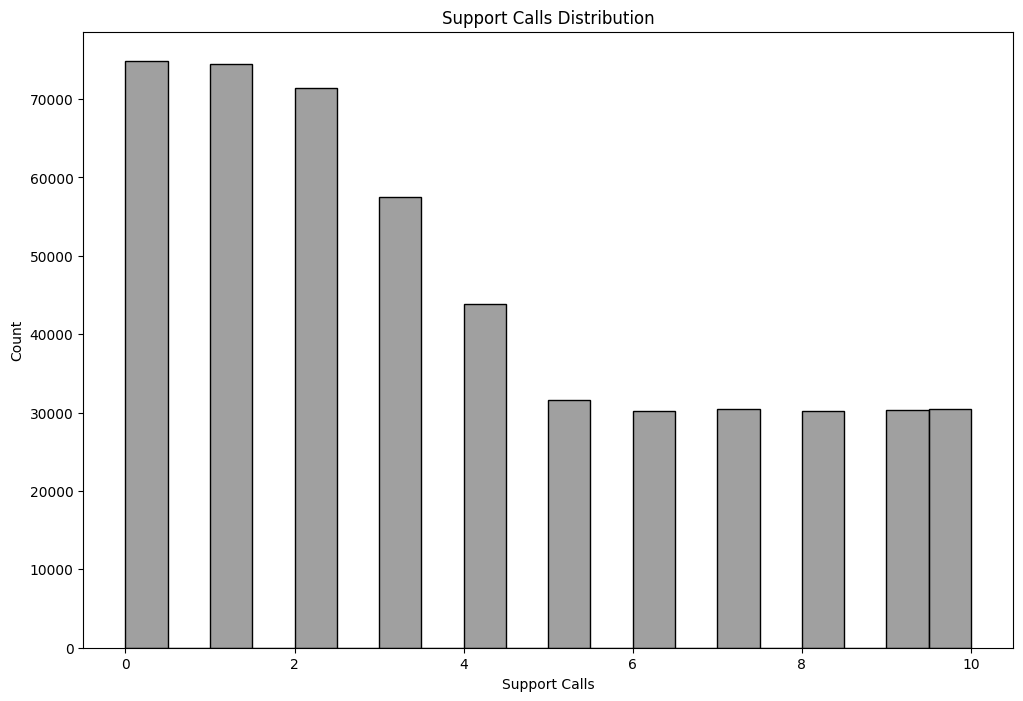

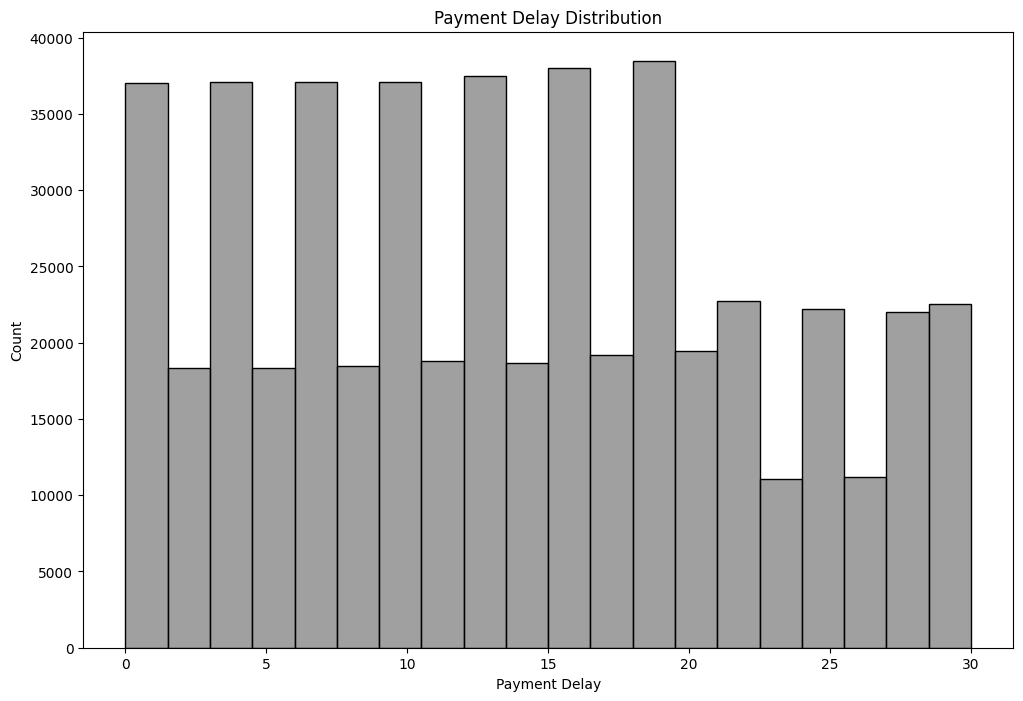

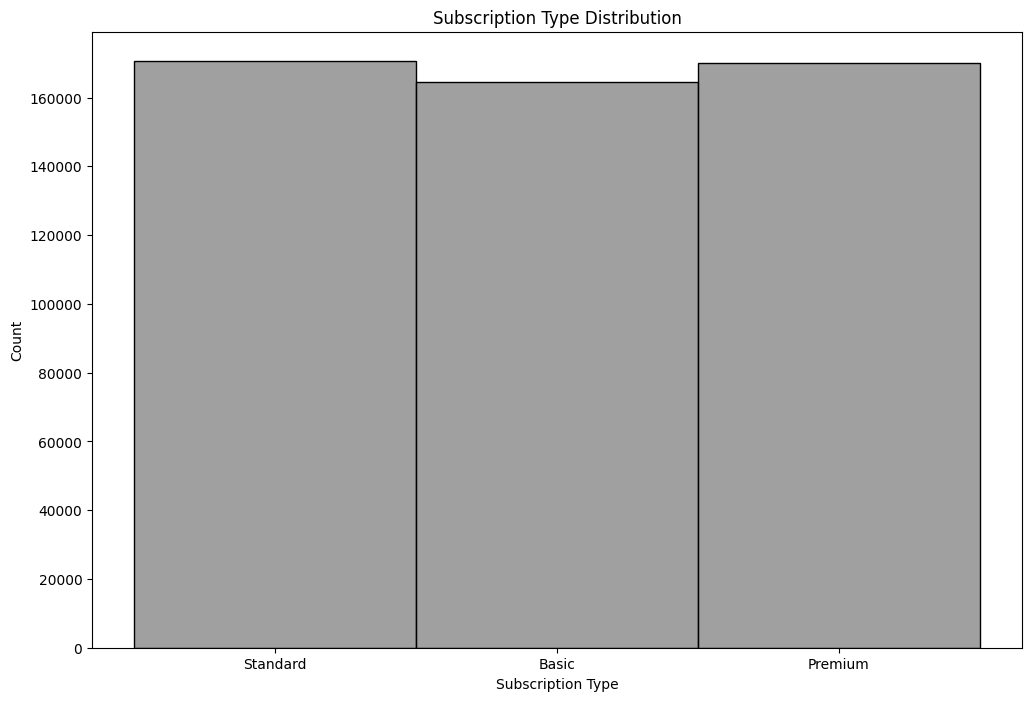

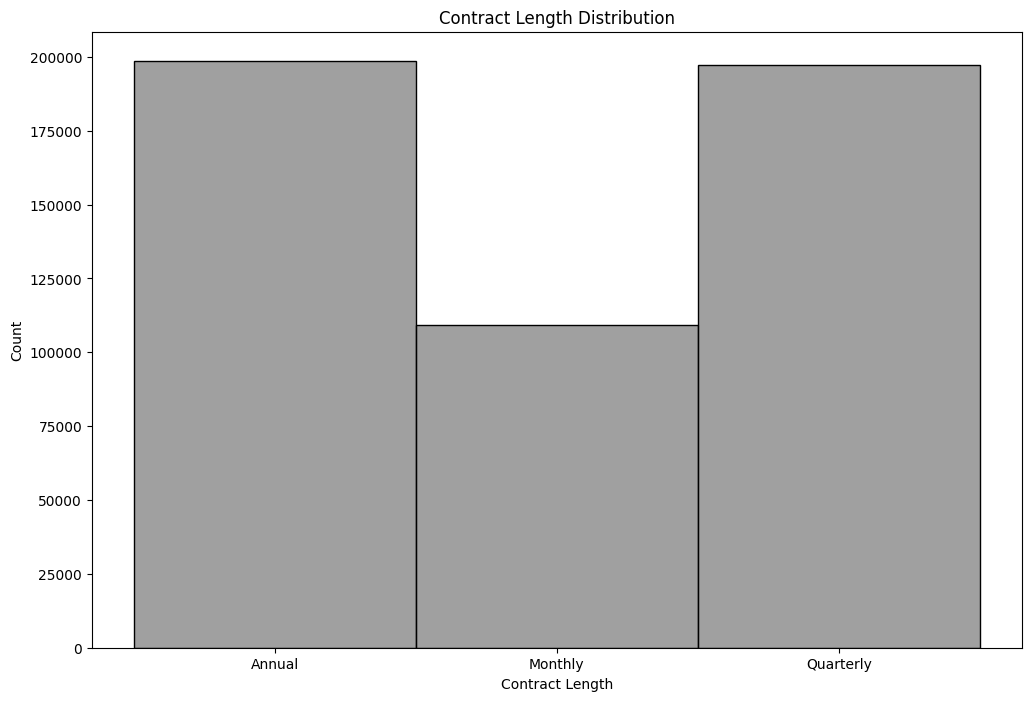

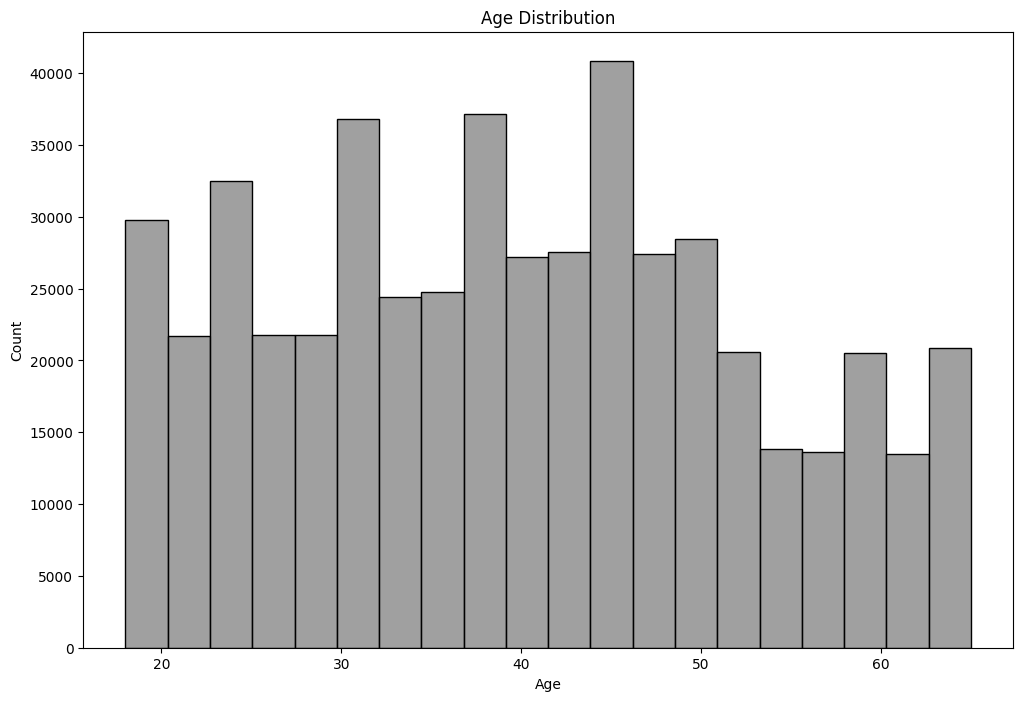

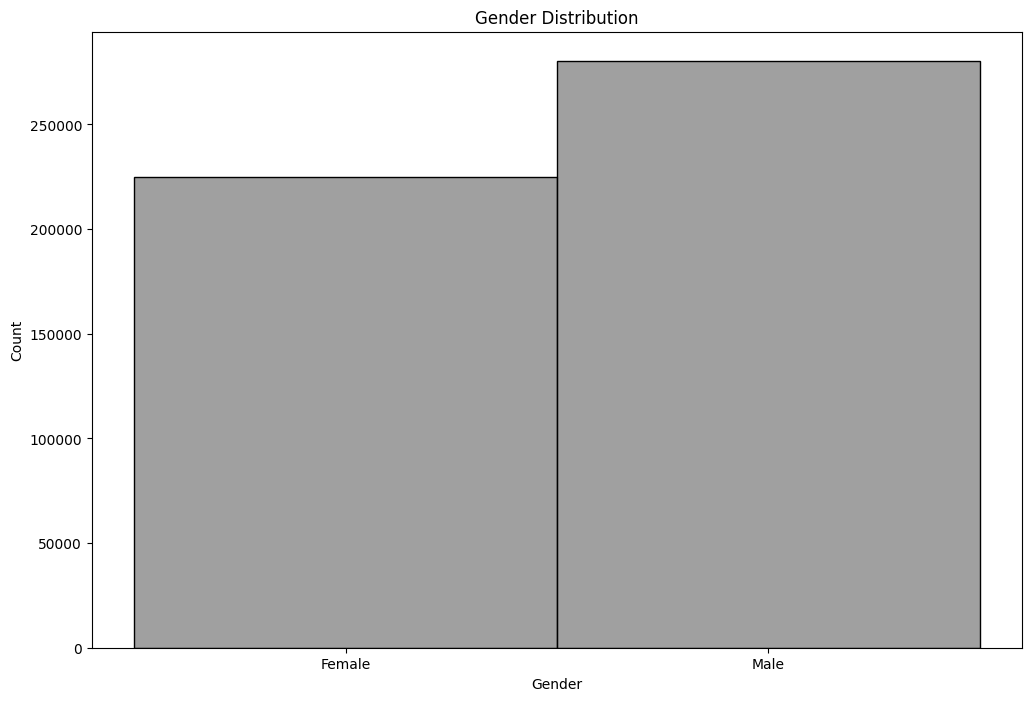

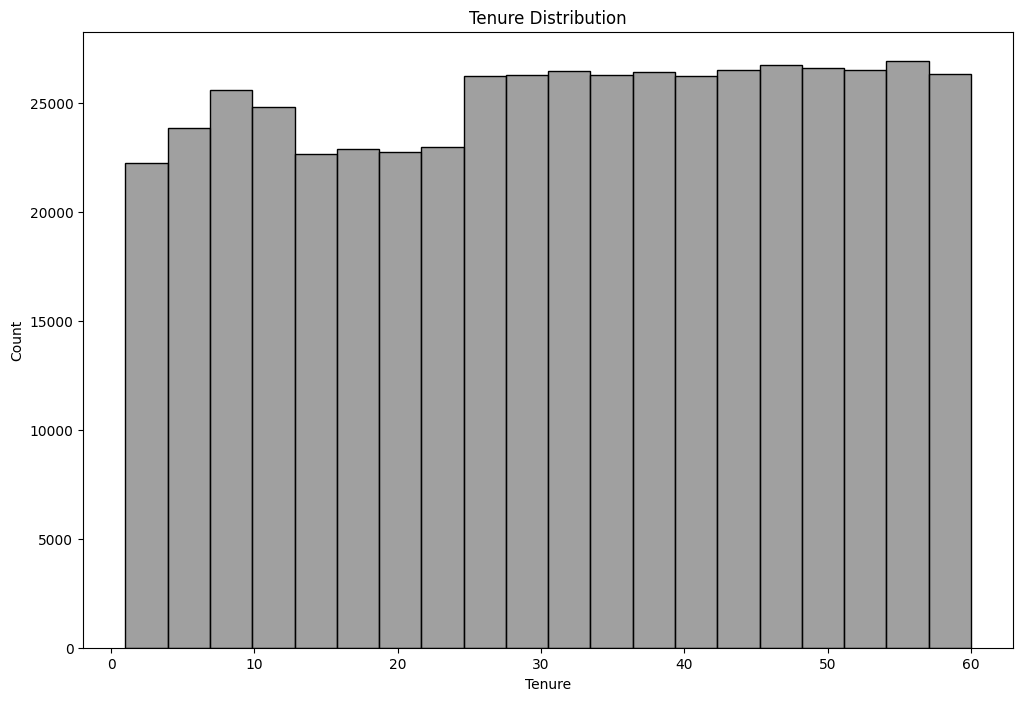

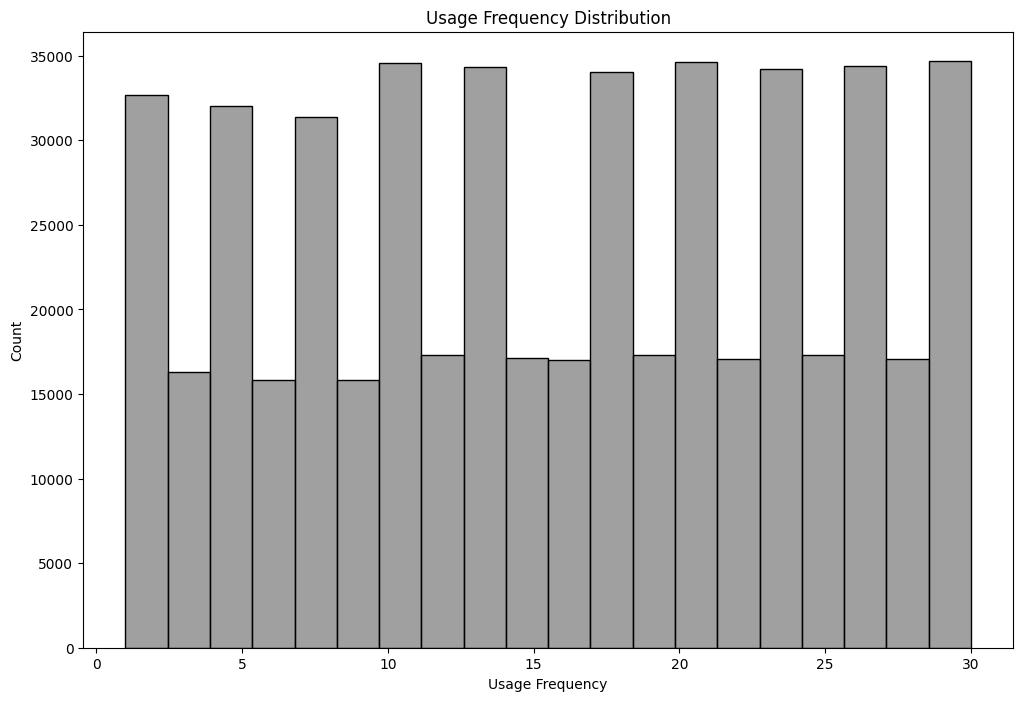

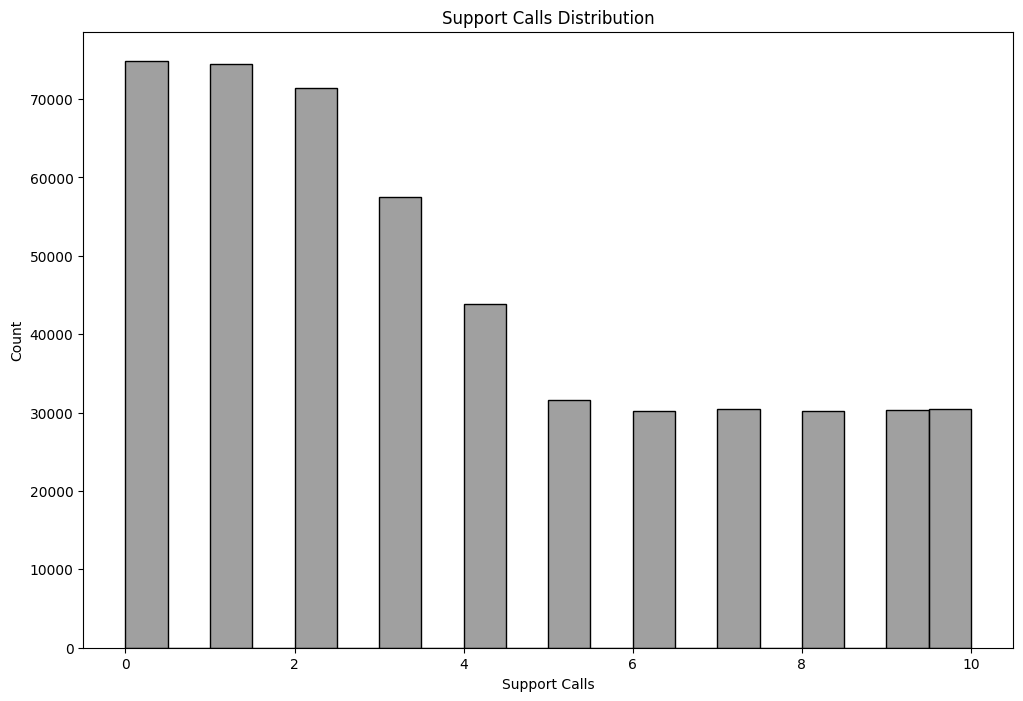

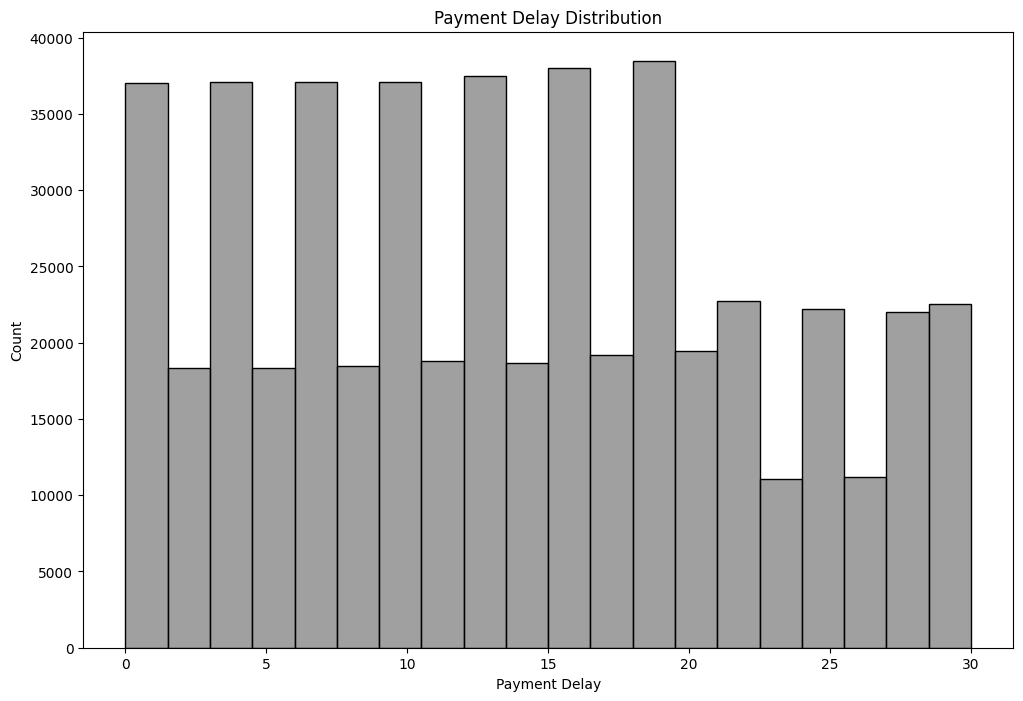

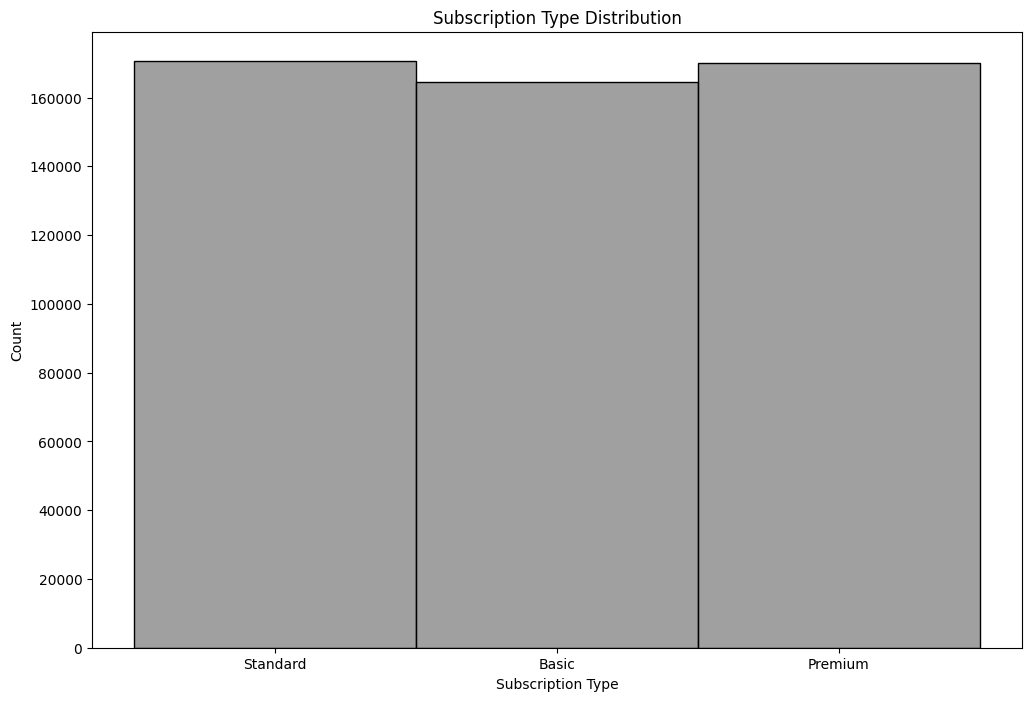

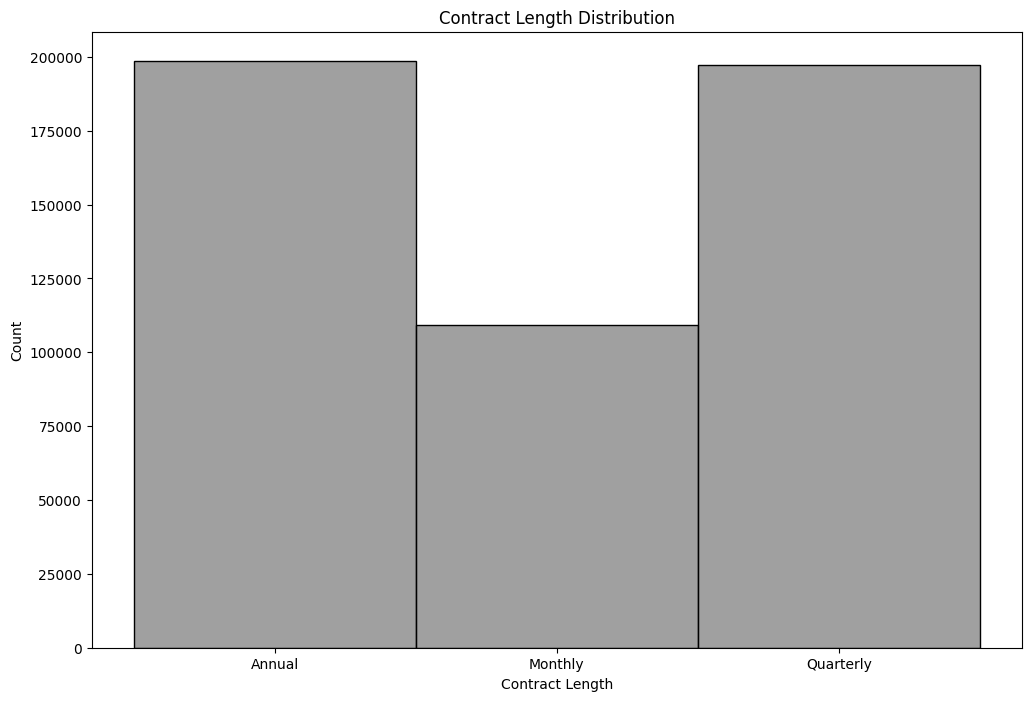

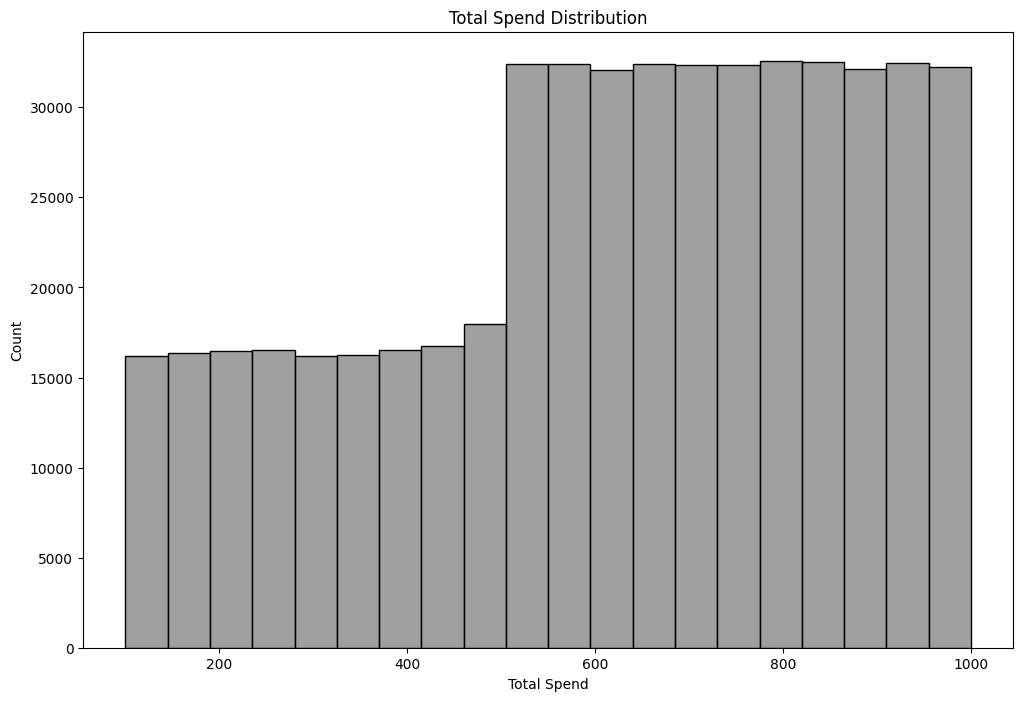

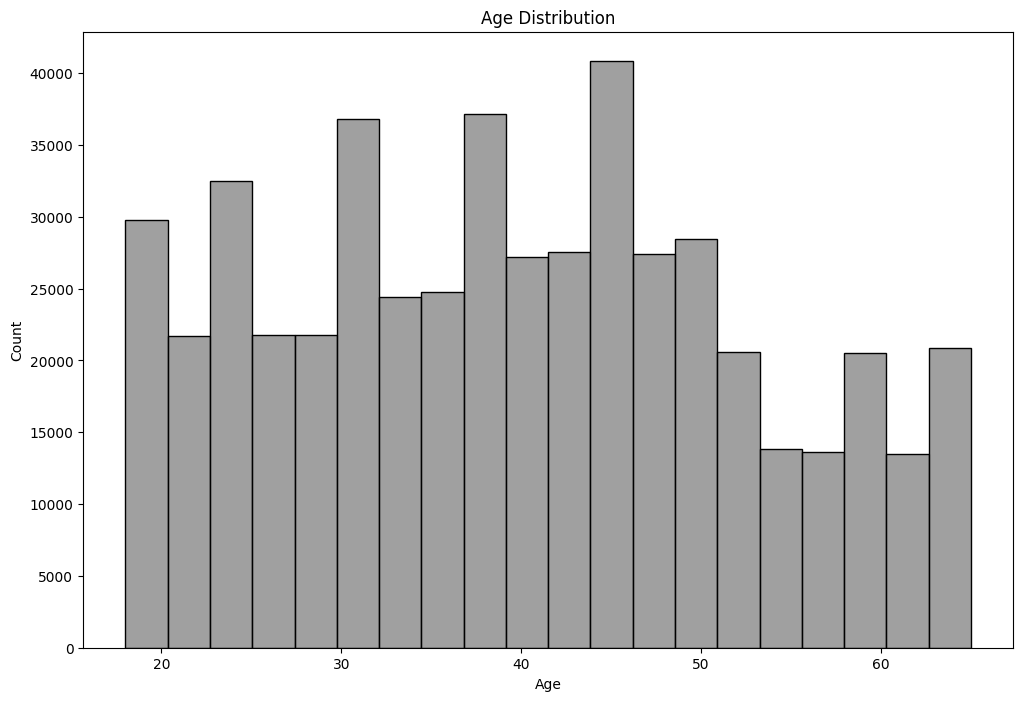

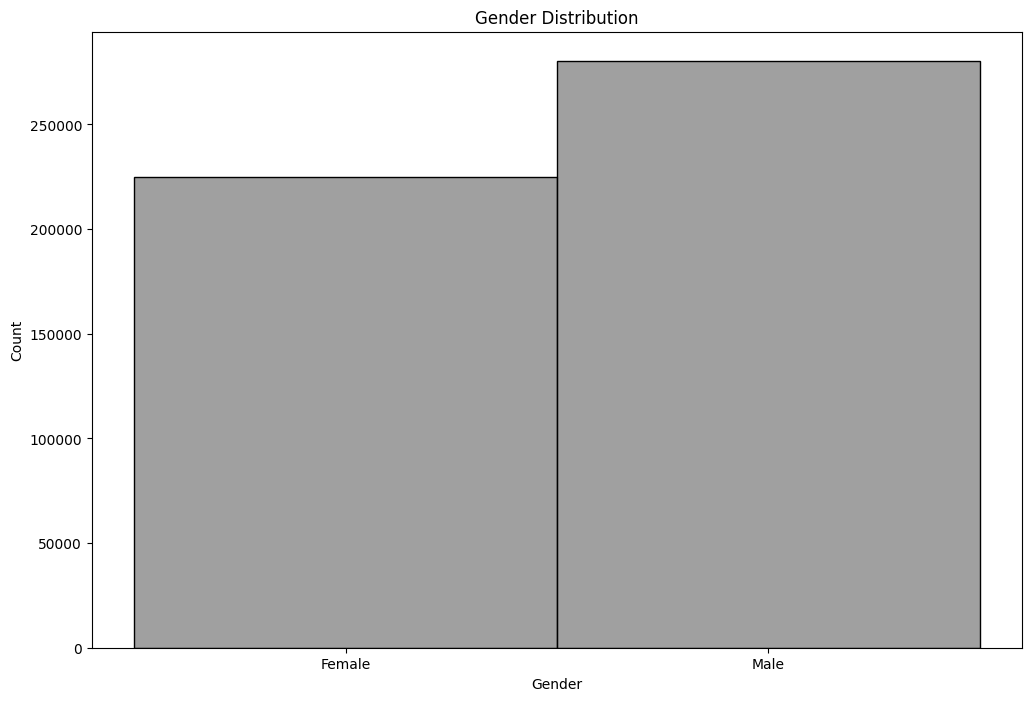

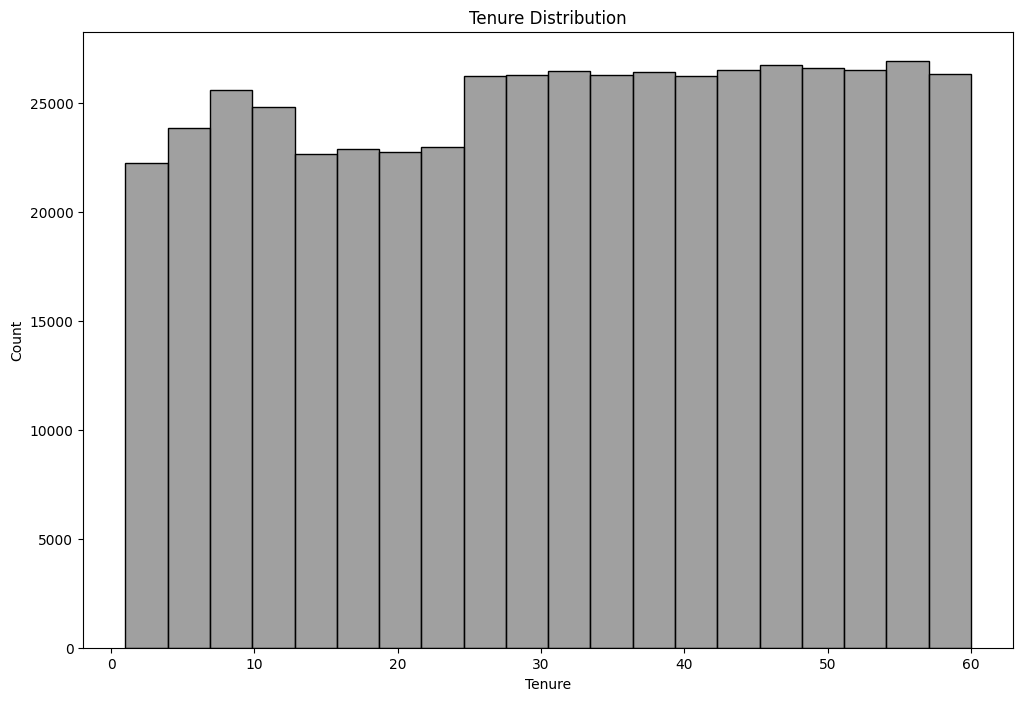

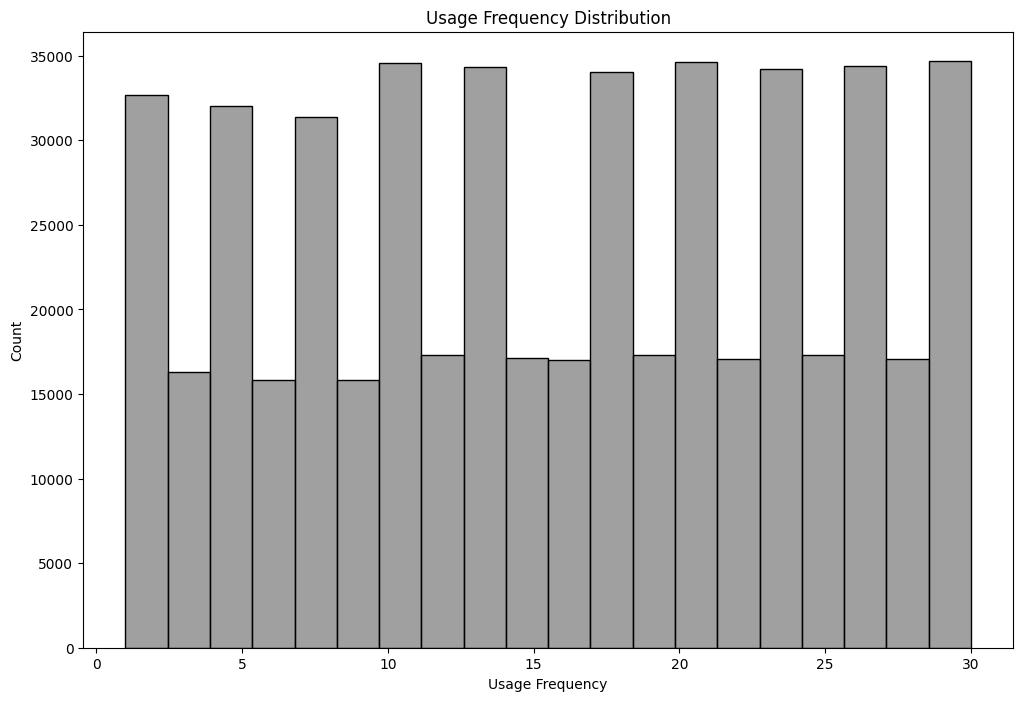

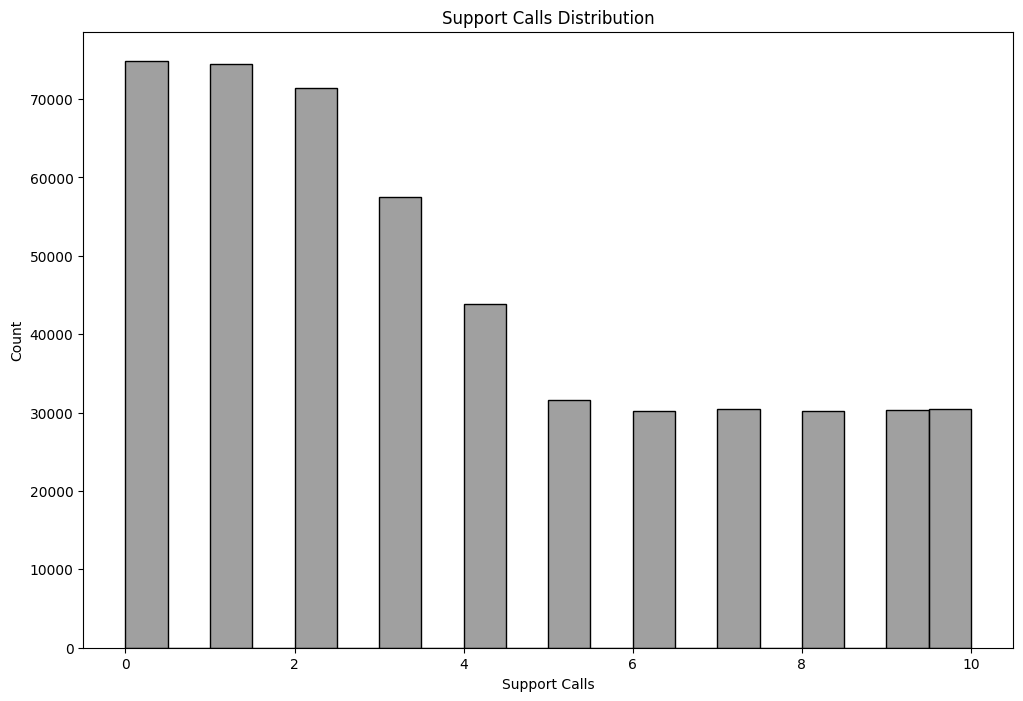

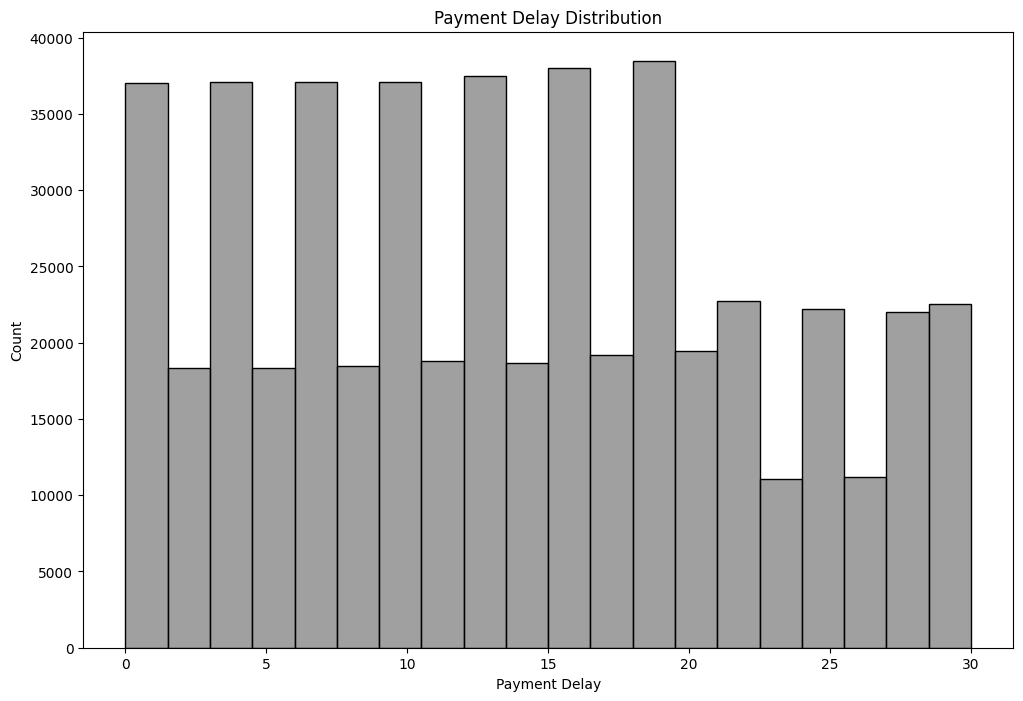

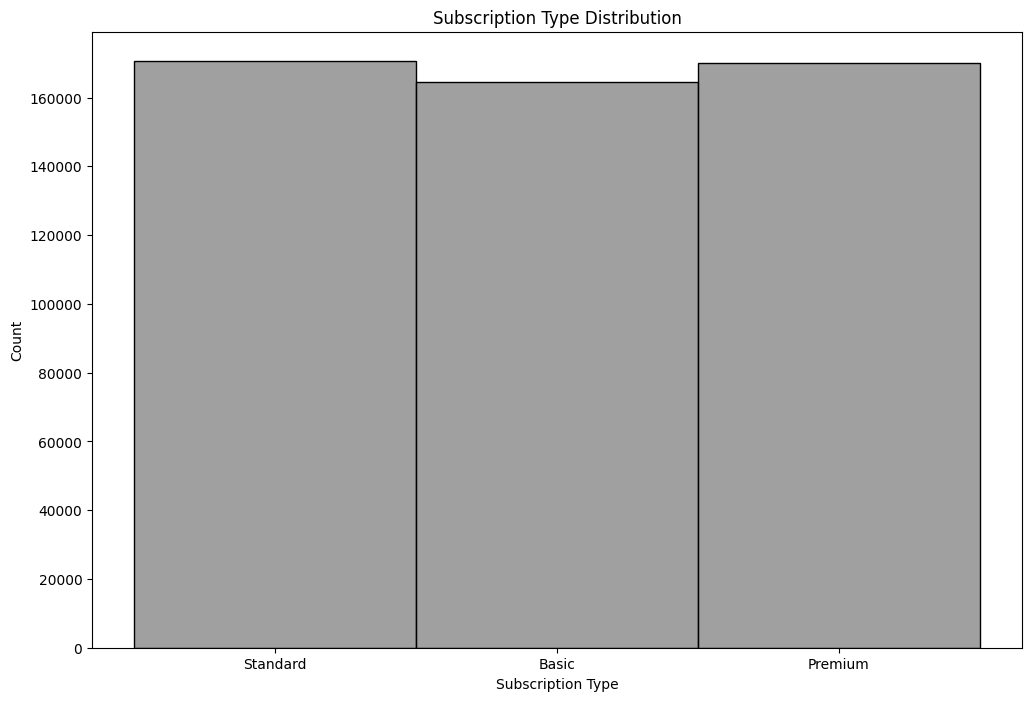

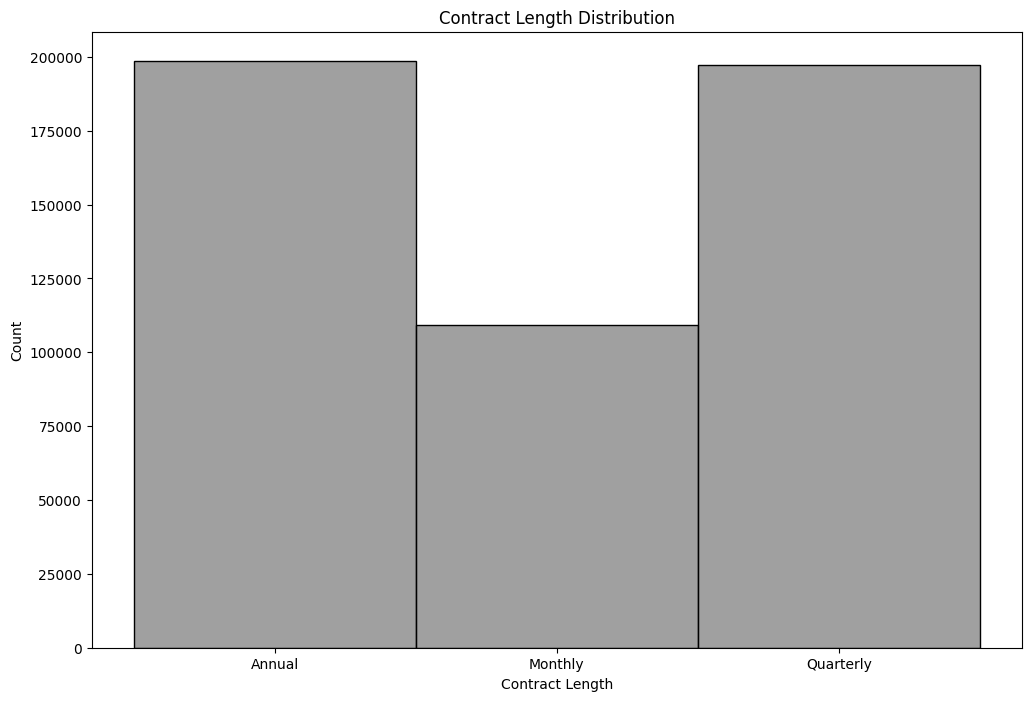

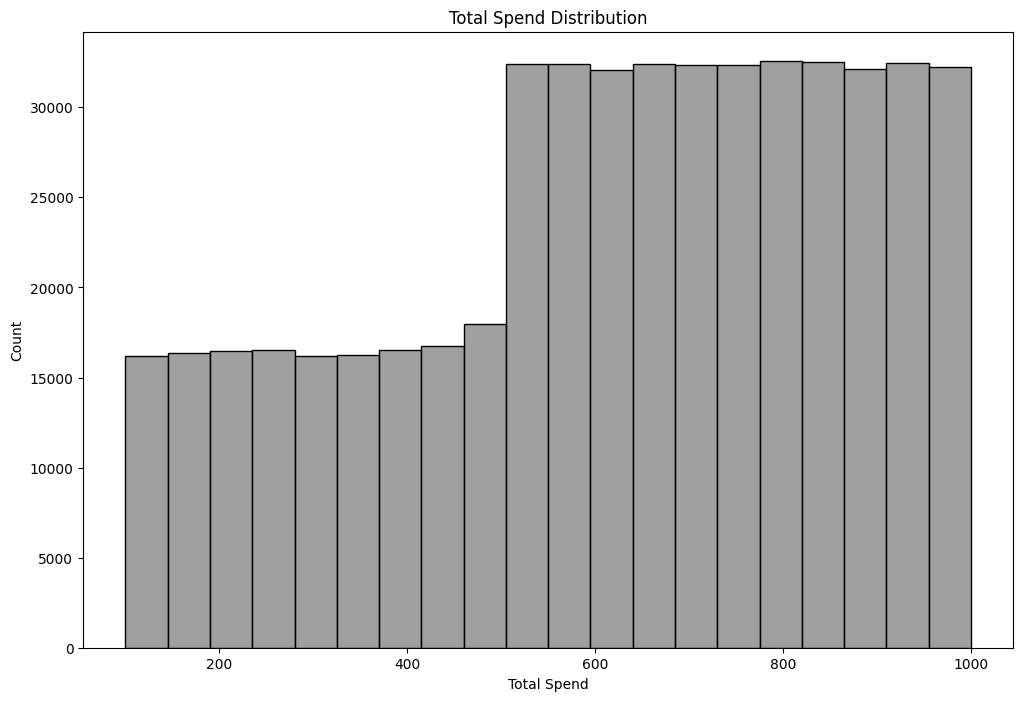

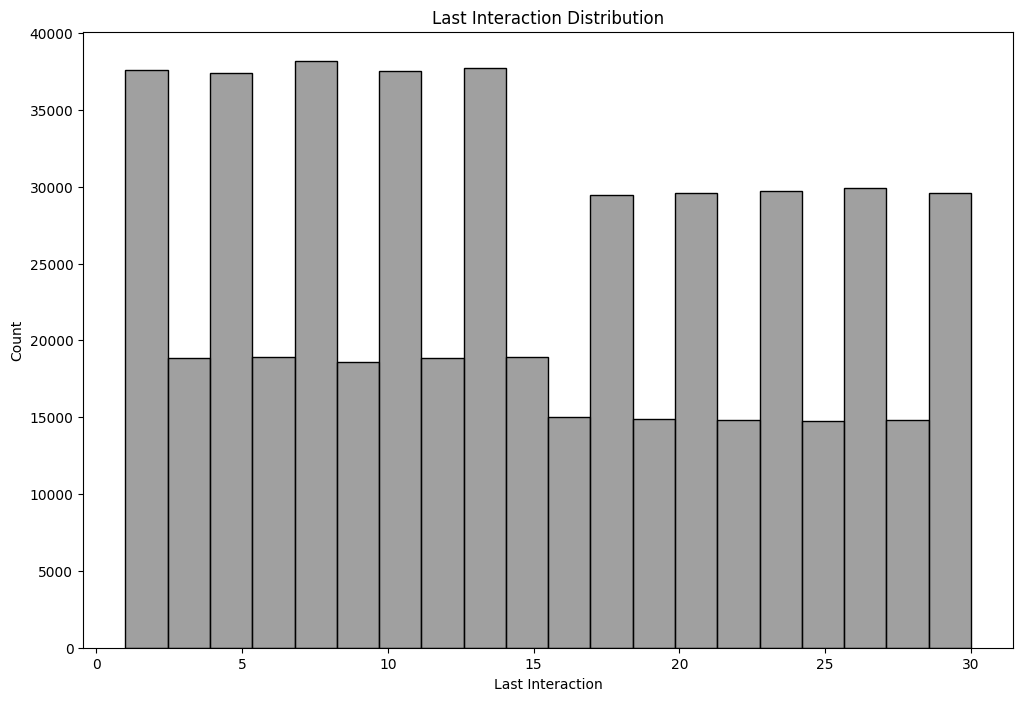

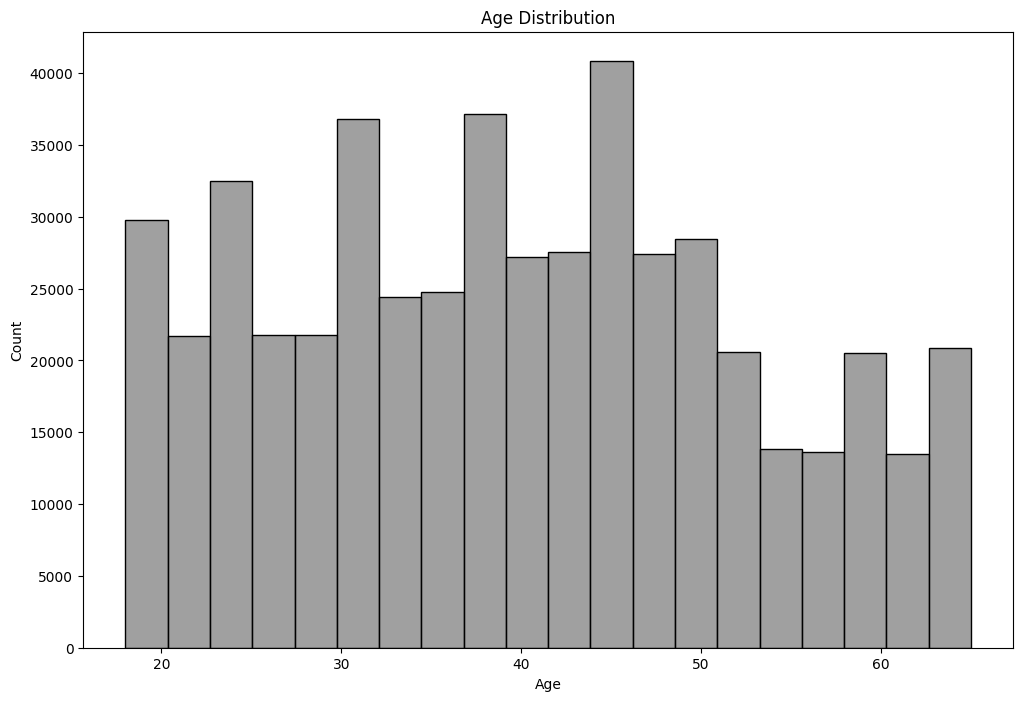

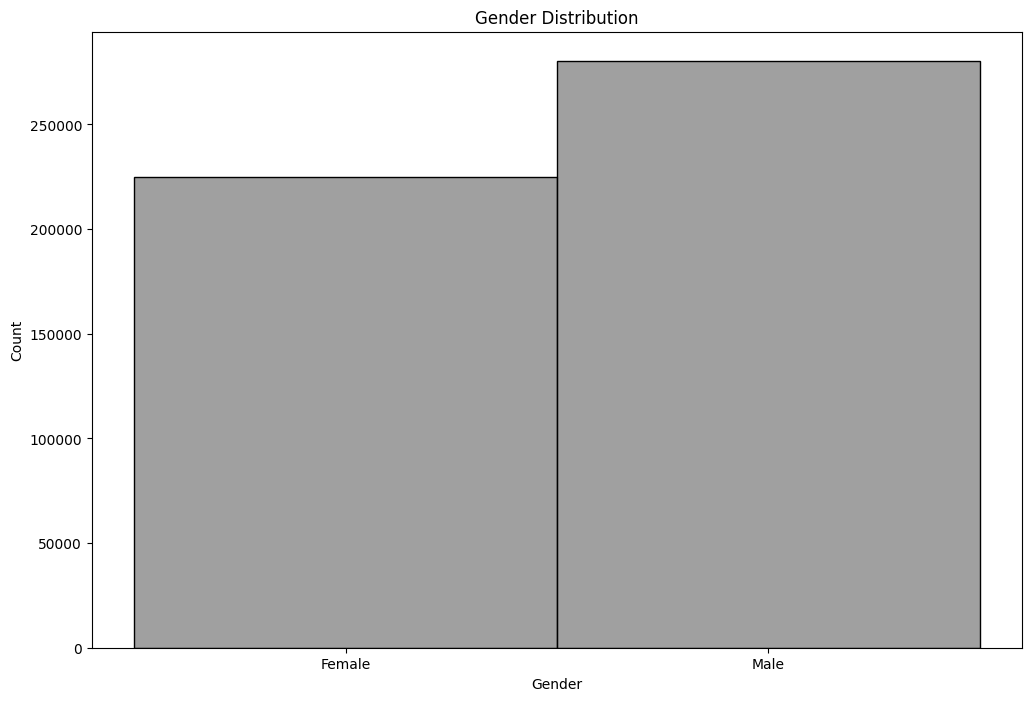

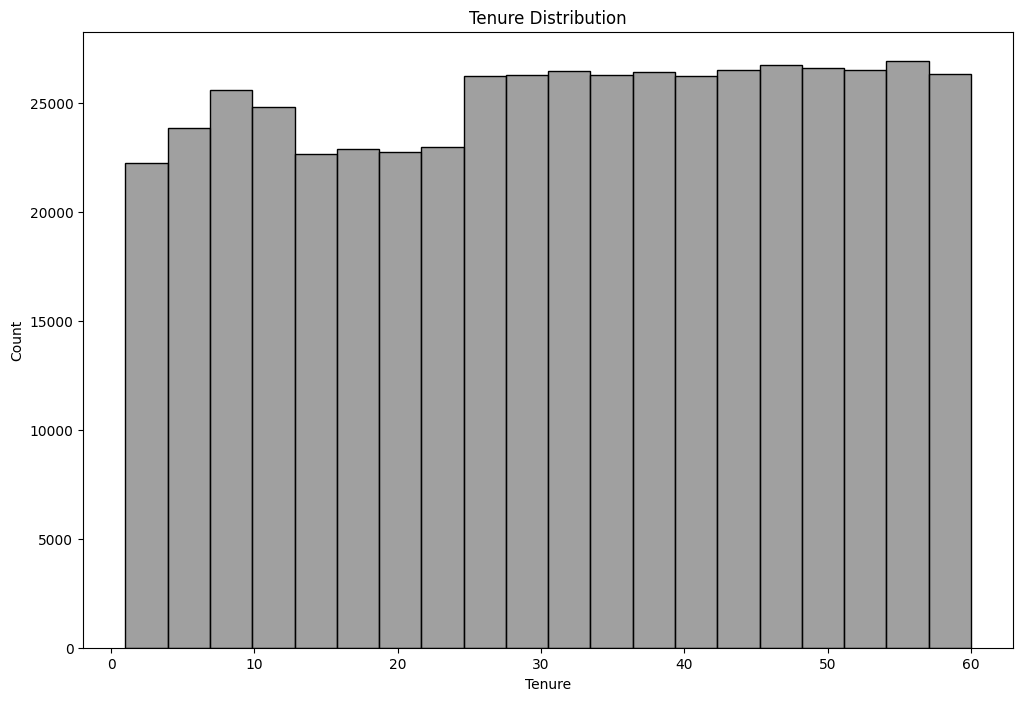

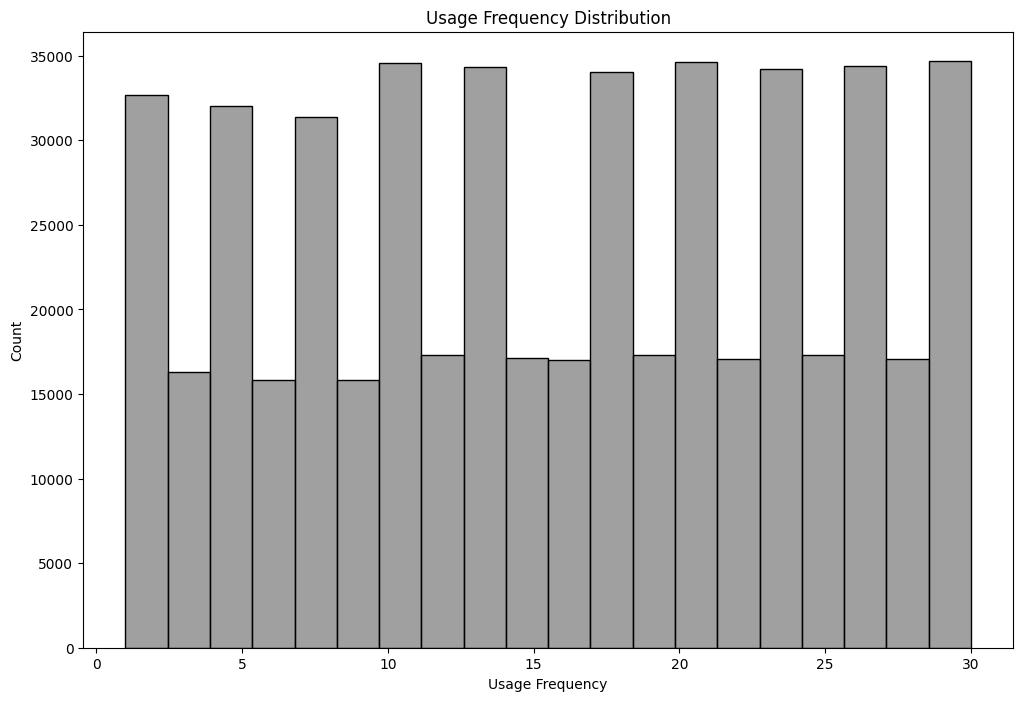

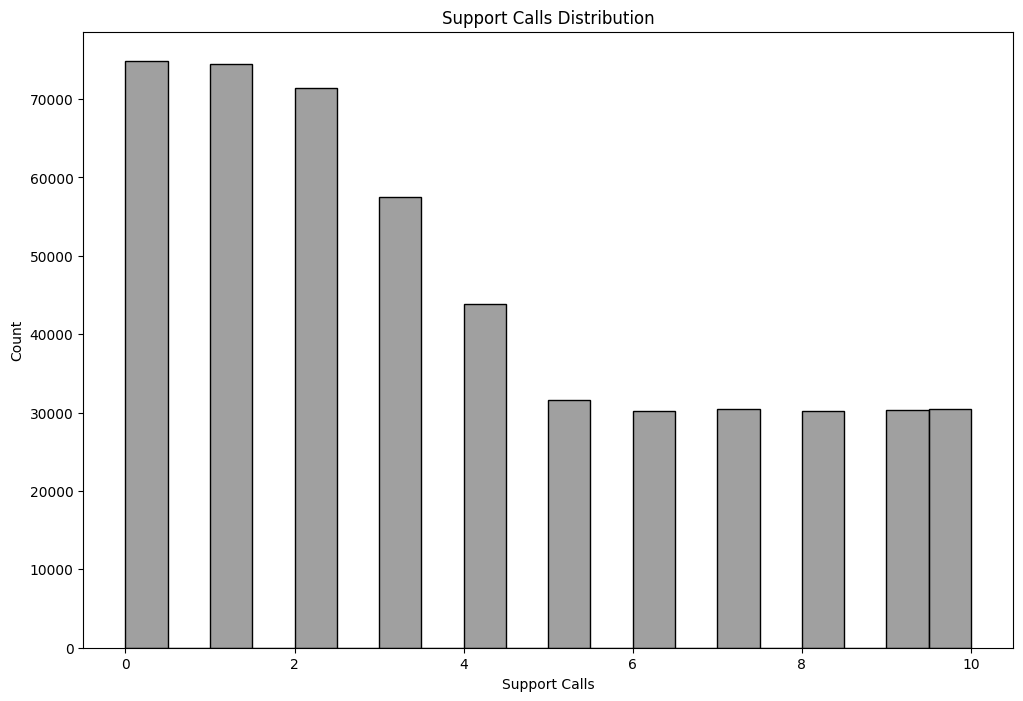

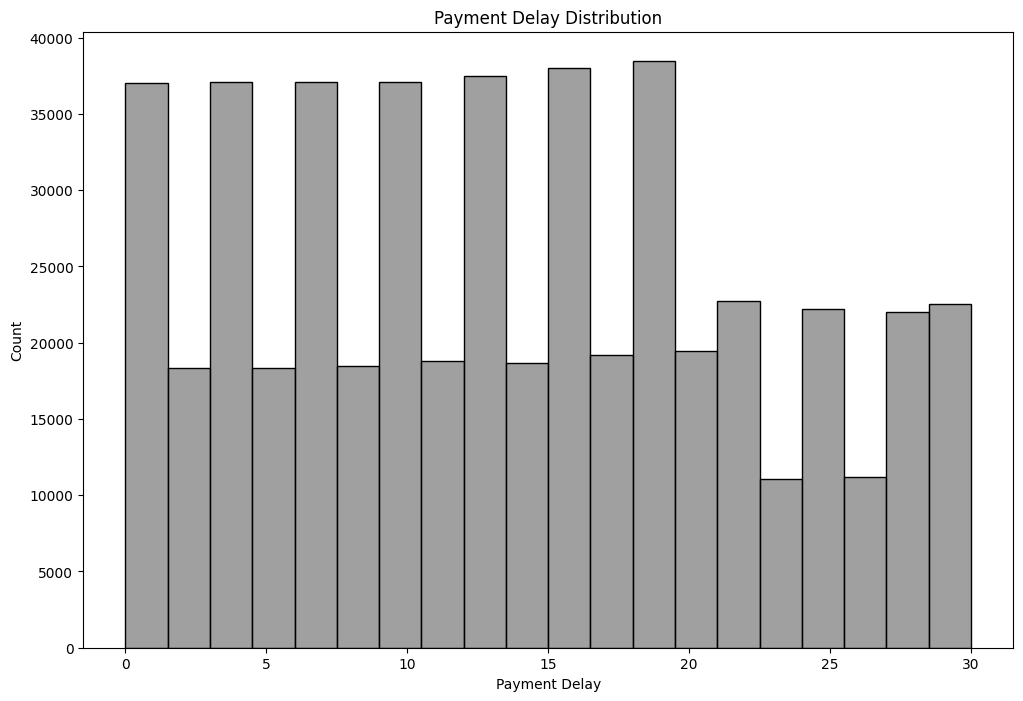

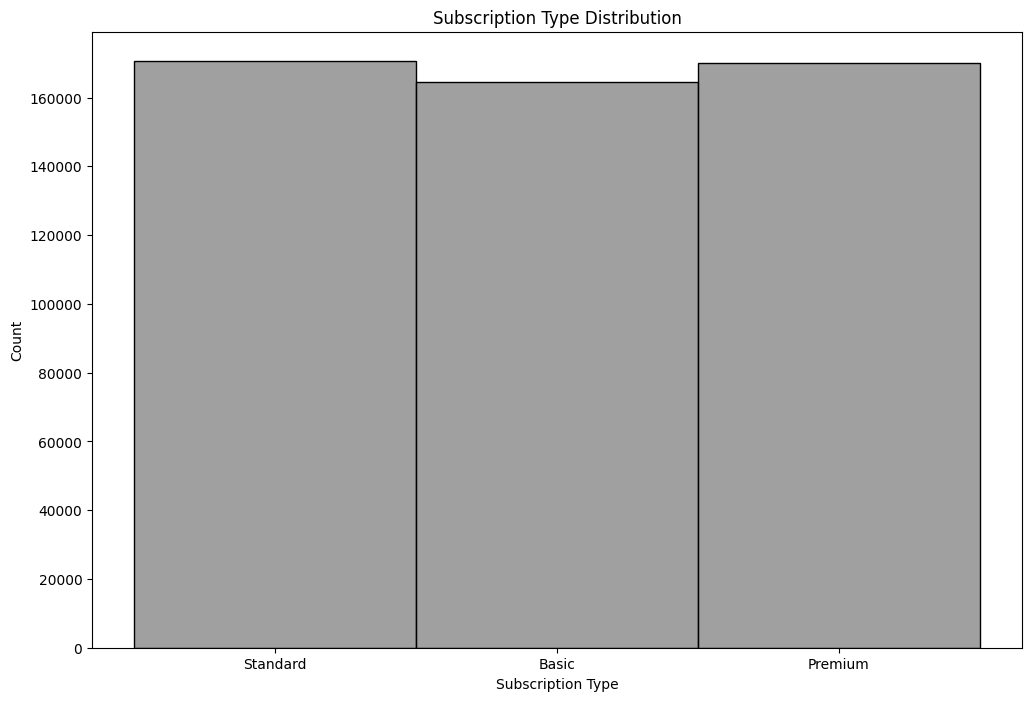

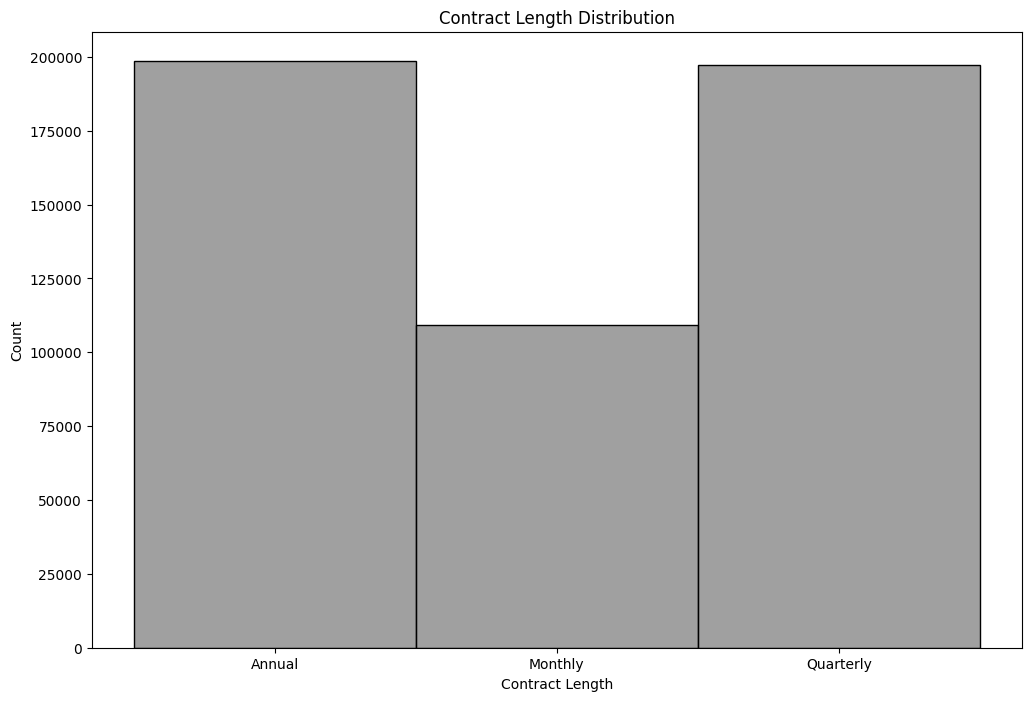

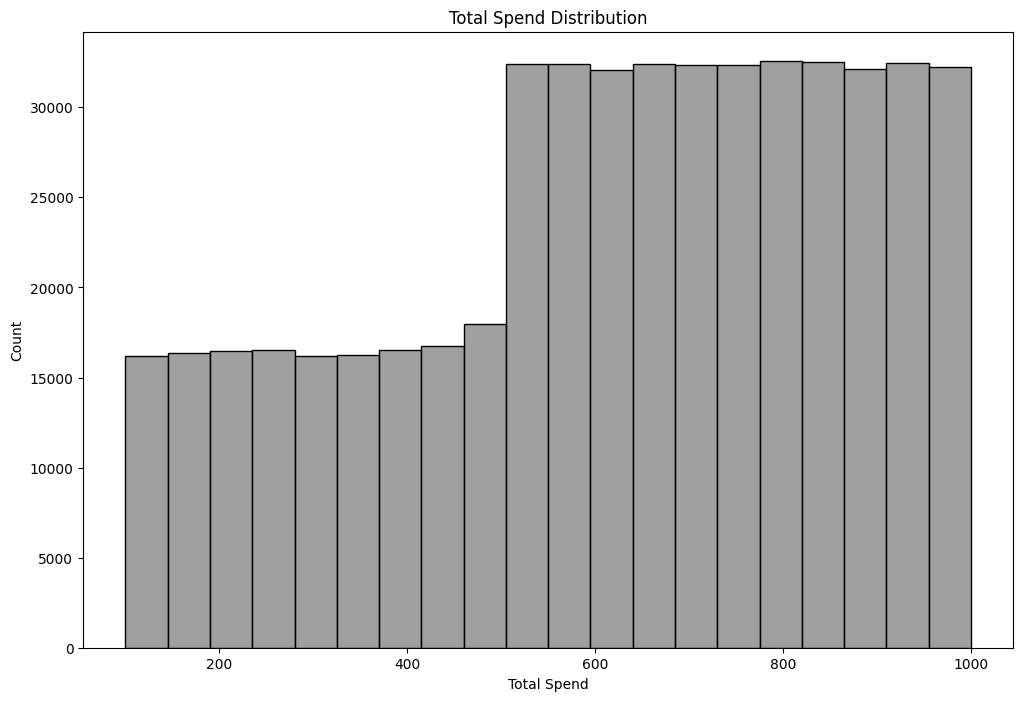

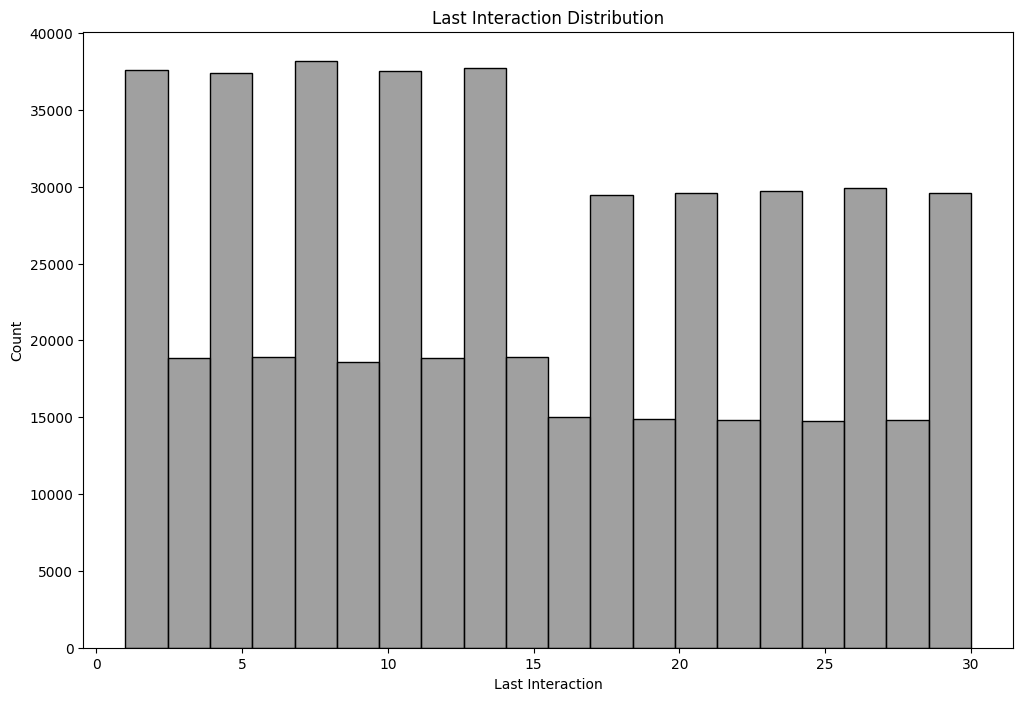

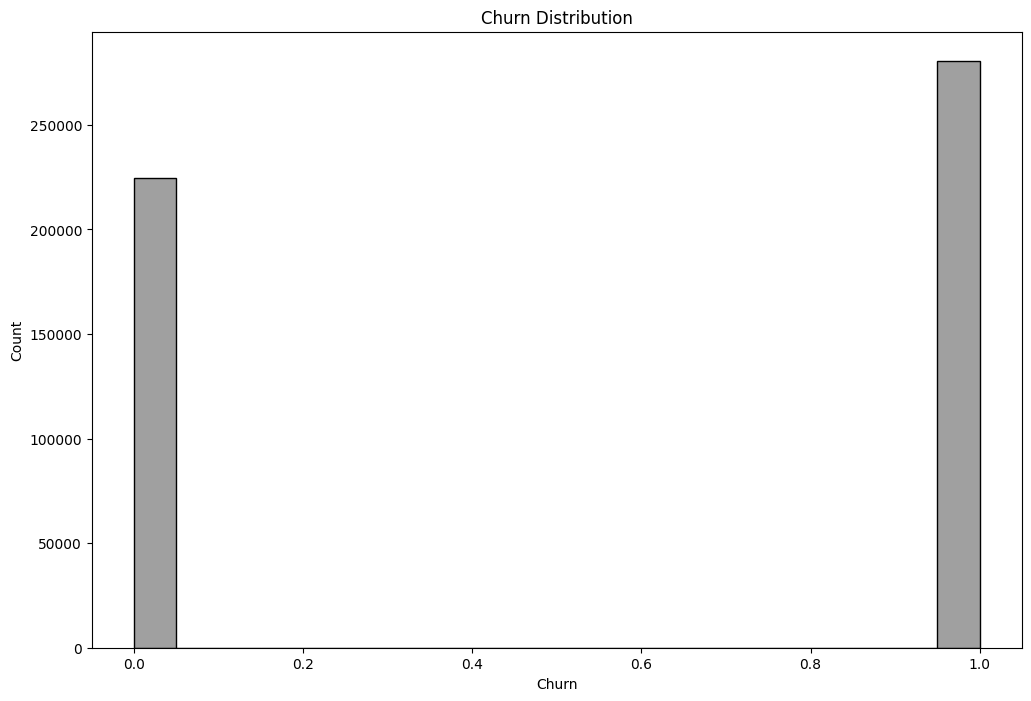

In [34]:
for c in df.columns:
    plt.figure(figsize = (12, 8))
    sns.histplot(df[c],
                 color = 'grey',
                 edgecolor = 'black',
                 bins = 20)
    plt.title(f'{c} Distribution')
    plt.show()

In [33]:
X = df.drop(columns = 'Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = .2,
                                                    stratify = y,
                                                    random_state = 30)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (404164, 10)
X_test: (101042, 10)


In [68]:
ohe_cols = ['Subscription Type', 'Contract Length', 'Gender']
num_cols = df.select_dtypes('number').drop(columns = 'Churn').columns


preprocessor = ColumnTransformer(transformers = [
    ('ohe', OneHotEncoder(drop = 'first', sparse_output = False), ohe_cols),
    ('scaler', MinMaxScaler(), num_cols)
], remainder = 'passthrough')

In [69]:
X_numeric = X_train.select_dtypes(include=[np.number])
X_vif_input = add_constant(X_numeric)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_input.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_input.values, i) for i in range(X_vif_input.shape[1])]

vif_results = vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_results)

            Feature       VIF
4     Support Calls  1.092039
6       Total Spend  1.058178
5     Payment Delay  1.042671
1               Age  1.025647
7  Last Interaction  1.007847
3   Usage Frequency  1.001428
2            Tenure  1.000803


In [63]:
# CONFIG
random_state = 30
n_splits     = 5
n_trials     = 50
scoring      = "recall"
thresholds = [.2, .25, .3, .35, .4, .45, .5]
results    = []

skf = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = random_state)

test_proba = {}

## Logisitic Regression

In [ ]:
def objective_lr(trial):
    params = {
        "C"           : trial.suggest_float("C", 0.001, 10.0, log = True),
        "max_iter"    : trial.suggest_int("max_iter", 200, 1000),
        "class_weight": trial.suggest_categorical("class_weight", [None, 'balanced']),
    }
    model = LogisticRegression(**params, random_state = 30)
    
    ml_pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_val_score(ml_pipeline, X_train, y_train,
                           cv = skf, scoring = scoring, n_jobs=-1).mean()
    return scores.mean() - (scores.std() * .5)

study_lr = optuna.create_study(
    direction="maximize",
    sampler = optuna.samplers.TPESampler(seed = random_state)
)
study_lr.optimize(objective_lr, n_trials= n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_lr.best_value:.3f}")
print(f"  Best params      : {study_lr.best_params}")

lr_best = ml_pipeline = Pipeline([
        ('scaler/encoder', clone(preprocessor)),
        ('classifier', LogisticRegression(**study_lr.best_params, random_state = random_state))
    ])
lr_best.fit(X_train, y_train)

lr_proba = lr_best.predict_proba(X_test)[:, 1]
lr_pred = lr_best.predict(X_test)
test_proba["Logistic Regression"] = lr_proba


print("  Classification Report:")
print(classification_report(y_test, lr_pred, digits = 2))

[I 2026-05-04 23:32:21,841] A new study created in memory with name: no-name-276cd7bd-cd98-4f59-a7a8-1dd4b59673e5
Best trial: 0. Best value: 0.849313:   2%|▏         | 1/50 [00:04<03:27,  4.23s/it]

[I 2026-05-04 23:32:26,067] Trial 0 finished with value: 0.8493134879133948 and parameters: {'C': 0.3772021367830892, 'max_iter': 504, 'class_weight': None}. Best is trial 0 with value: 0.8493134879133948.


Best trial: 0. Best value: 0.849313:   4%|▍         | 2/50 [00:06<02:28,  3.10s/it]

[I 2026-05-04 23:32:28,383] Trial 1 finished with value: 0.8492956615091594 and parameters: {'C': 7.086491241497787, 'max_iter': 477, 'class_weight': None}. Best is trial 0 with value: 0.8493134879133948.


Best trial: 0. Best value: 0.849313:   6%|▌         | 3/50 [00:08<02:06,  2.69s/it]

...

[I 2026-05-04 23:34:02,934] Trial 47 finished with value: 0.8198295038525888 and parameters: {'C': 2.79850126291106, 'max_iter': 696, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.8493357702484078.


Best trial: 40. Best value: 0.849336:  98%|█████████▊| 49/50 [01:43<00:02,  2.05s/it]

[I 2026-05-04 23:34:04,928] Trial 48 finished with value: 0.8493001180357425 and parameters: {'C': 0.9053560163861906, 'max_iter': 625, 'class_weight': None}. Best is trial 40 with value: 0.8493357702484078.


Best trial: 40. Best value: 0.849336: 100%|██████████| 50/50 [01:45<00:00,  2.10s/it]


[I 2026-05-04 23:34:06,939] Trial 49 finished with value: 0.8493268572945425 and parameters: {'C': 0.7033253703593092, 'max_iter': 585, 'class_weight': None}. Best is trial 40 with value: 0.8493357702484078.

✔ Best CV recall : 0.849
  Best params      : {'C': 0.8087090578905786, 'max_iter': 621, 'class_weight': None}
  Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83     44943
           1       0.87      0.85      0.86     56099

    accuracy                           0.85    101042
   macro avg       0.85      0.85      0.85    101042
weighted avg       0.85      0.85      0.85    101042



## XGBoost

In [71]:
def objective_xgb(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 800),
        "max_depth"       : trial.suggest_int("max_depth", 3, 7),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 0.0001, 10.0, log = True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 0.0001, 10.0, log = True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0)
    }    
    model = XGBClassifier(
        **params, random_state = random_state,
        eval_metric="logloss", verbosity=0, n_jobs=-1
    )
    
    ml_pipeline = Pipeline([
        ('scaler/encoder', clone(preprocessor)),
        ('classifier', model)
    ])

    scores = cross_val_score(ml_pipeline, X_train, y_train,
                           cv = skf, scoring = scoring, n_jobs=-1).mean()
    
    return scores.mean() - (scores.std() * .5)

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed = random_state)
)
study_xgb.optimize(objective_xgb, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_xgb.best_value:.2f}")
print(f"  Best params      : {study_xgb.best_params}")

xgb_best = ml_pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', XGBClassifier(**study_xgb.best_params, random_state = random_state, eval_metric="logloss", verbosity=0, n_jobs=-1))
    ])
xgb_best.fit(X_train, y_train)
xgb_pred = xgb_best.predict(X_test)
xgb_proba = xgb_best.predict_proba(X_test)[:, 1]

test_proba["XGBoost"] = xgb_proba 

print("  Classification Report:")
print(classification_report(y_test, xgb_pred, digits = 2))

[I 2026-05-04 23:35:48,836] A new study created in memory with name: no-name-4be4b00c-1760-4b60-aa93-827597b369f2
Best trial: 0. Best value: 0.999777:   2%|▏         | 1/50 [00:35<28:52, 35.35s/it]

[I 2026-05-04 23:36:24,183] Trial 0 finished with value: 0.9997771763519662 and parameters: {'n_estimators': 587, 'max_depth': 4, 'learning_rate': 0.0953678855701606, 'subsample': 0.5818253630513767, 'colsample_bytree': 0.9813039068371594, 'reg_alpha': 0.005411394574695545, 'reg_lambda': 9.094000242878604, 'min_child_weight': 3, 'scale_pos_weight': 6.271248416694919}. Best is trial 0 with value: 0.9997771763519662.


Best trial: 0. Best value: 0.999777:   4%|▍         | 2/50 [00:57<22:10, 27.71s/it]

[I 2026-05-04 23:36:46,554] Trial 1 finished with value: 0.9993092476145937 and parameters: {'n_estimators': 444, 'max_depth': 3, 'learning_rate': 0.06364367889969569, 'subsample': 0.7590881734129227, 'colsample_bytree': 0.8834275531492527, 'reg_alpha': 4.669288588199327, 'reg_lambda': 0.000280877476051184, 'min_child_weight': 2, 'scale_pos_weight': 9.947743158676253}. Best is trial 0 with value: 0.9997771763519662.


Best trial: 0. Best value: 0.999777:   6%|▌         | 3/50 [01:18<19:23, 24.75s/it]

...

[I 2026-05-05 00:11:36,430] Trial 47 finished with value: 0.9998217411212933 and parameters: {'n_estimators': 714, 'max_depth': 6, 'learning_rate': 0.08354156535598073, 'subsample': 0.5311853524634307, 'colsample_bytree': 0.7537289542296285, 'reg_alpha': 3.194132768859187, 'reg_lambda': 6.6031615595157565, 'min_child_weight': 2, 'scale_pos_weight': 8.628546529581003}. Best is trial 33 with value: 0.9998351106017418.


Best trial: 33. Best value: 0.999835:  98%|█████████▊| 49/50 [36:32<00:52, 52.83s/it]

[I 2026-05-05 00:12:21,215] Trial 48 finished with value: 0.9997771764512671 and parameters: {'n_estimators': 469, 'max_depth': 5, 'learning_rate': 0.03329232382641602, 'subsample': 0.5664908871295219, 'colsample_bytree': 0.7978528682089409, 'reg_alpha': 1.3670645316009347, 'reg_lambda': 0.016008620969317853, 'min_child_weight': 4, 'scale_pos_weight': 7.418064440999839}. Best is trial 33 with value: 0.9998351106017418.


Best trial: 33. Best value: 0.999835: 100%|██████████| 50/50 [37:08<00:00, 44.57s/it]


[I 2026-05-05 00:12:57,524] Trial 49 finished with value: 0.9997727202225868 and parameters: {'n_estimators': 289, 'max_depth': 7, 'learning_rate': 0.04957603835972688, 'subsample': 0.6889898870439691, 'colsample_bytree': 0.6064243943888044, 'reg_alpha': 0.5269886185212912, 'reg_lambda': 7.170634787704445, 'min_child_weight': 1, 'scale_pos_weight': 9.099737315462948}. Best is trial 33 with value: 0.9998351106017418.

✔ Best CV recall : 1.00
  Best params      : {'n_estimators': 695, 'max_depth': 6, 'learning_rate': 0.06009017302068658, 'subsample': 0.5795549163537853, 'colsample_bytree': 0.6658311759073294, 'reg_alpha': 3.1808346530437857, 'reg_lambda': 1.231906795515966, 'min_child_weight': 5, 'scale_pos_weight': 9.96699446026307}
  Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.92     44943
           1       0.90      1.00      0.95     56099

    accuracy                           0.94    101042
   macro avg   

## LightGBM

In [72]:
def objective_lgbm(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 100, 500),
        "max_depth"       : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.001, 0.3, log = True),
        "num_leaves"      : trial.suggest_int("num_leaves", 20, 150),
        "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 0.0001, 10.0, log = True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 0.0001, 10.0, log = True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0)
    }
    model = LGBMClassifier(**params, random_state = random_state, n_jobs=-1, verbose=-1)
    
    ml_pipeline = Pipeline([
        ('scaler/encoder', clone(preprocessor)),
        ('classifier', model)
    ])
    
    scores = cross_val_score(ml_pipeline, X_train, y_train,
                           cv = skf, scoring = scoring, n_jobs=-1).mean()
    
    return scores.mean() -  (scores.std() * .5)

study_lgbm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed = random_state)
)
study_lgbm.optimize(objective_lgbm, n_trials = n_trials, show_progress_bar = True)

print(f"\n✔ Best CV {scoring} : {study_lgbm.best_value:.3f}")
print(f"  Best params      : {study_lgbm.best_params}")

lgbm_best = ml_pipeline = Pipeline([
        ('scaler/encoder', preprocessor),
        ('classifier', LGBMClassifier(**study_lgbm.best_params, random_state = random_state, n_jobs=-1, verbose=-1))
    ])
lgbm_best.fit(X_train, y_train)

lgbm_proba = lgbm_best.predict_proba(X_test)[:, 1]
lgbm_pred = lgbm_best.predict(X_test)
test_proba["LightGBM"] = lgbm_proba

print("  Classification Report:")
print(classification_report(y_test, lgbm_pred, digits = 2))

[I 2026-05-05 00:13:13,938] A new study created in memory with name: no-name-ce356c9a-0b4a-459a-9d95-7cb6844a1a8b
Best trial: 0. Best value: 0.999385:   2%|▏         | 1/50 [00:26<21:58, 26.90s/it]

[I 2026-05-05 00:13:40,839] Trial 0 finished with value: 0.9993850068783919 and parameters: {'n_estimators': 358, 'max_depth': 6, 'learning_rate': 0.043898538252232056, 'num_leaves': 41, 'subsample': 0.9813039068371594, 'colsample_bytree': 0.6733309201898828, 'reg_alpha': 9.094000242878604, 'reg_lambda': 0.0014972333011202422, 'scale_pos_weight': 6.271248416694919}. Best is trial 0 with value: 0.9993850068783919.


Best trial: 0. Best value: 0.999385:   4%|▍         | 2/50 [00:40<15:20, 19.18s/it]

[I 2026-05-05 00:13:54,619] Trial 1 finished with value: 0.9953073394716927 and parameters: {'n_estimators': 263, 'max_depth': 4, 'learning_rate': 0.022278788139007213, 'num_leaves': 87, 'subsample': 0.8834275531492527, 'colsample_bytree': 0.9669250716592899, 'reg_alpha': 0.000280877476051184, 'reg_lambda': 0.0009524809181529287, 'scale_pos_weight': 9.947743158676253}. Best is trial 0 with value: 0.9993850068783919.


Best trial: 0. Best value: 0.999385:   6%|▌         | 3/50 [00:51<12:03, 15.39s/it]

...

Best trial: 8. Best value: 1: 100%|██████████| 50/50 [11:34<00:00, 13.88s/it]


[I 2026-05-05 00:24:48,162] Trial 49 finished with value: 0.9975266602177397 and parameters: {'n_estimators': 182, 'max_depth': 10, 'learning_rate': 0.0018108537861535924, 'num_leaves': 98, 'subsample': 0.7561637475099657, 'colsample_bytree': 0.5815447720720531, 'reg_alpha': 1.7301194767500099, 'reg_lambda': 0.08139945308263212, 'scale_pos_weight': 1.3735837638430213}. Best is trial 8 with value: 1.0.

✔ Best CV recall : 1.000
  Best params      : {'n_estimators': 297, 'max_depth': 4, 'learning_rate': 0.001192201220110662, 'num_leaves': 143, 'subsample': 0.6284188576231671, 'colsample_bytree': 0.5285673015045135, 'reg_alpha': 0.008680427662824819, 'reg_lambda': 0.00610216206304123, 'scale_pos_weight': 9.877457286866438}


d:\ML Projects\MSC_ML_Final_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML Projects\MSC_ML_Final_Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     44943
           1       0.56      1.00      0.71     56099

    accuracy                           0.56    101042
   macro avg       0.28      0.50      0.36    101042
weighted avg       0.31      0.56      0.40    101042



d:\ML Projects\MSC_ML_Final_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Projects\MSC_ML_Final_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Projects\MSC_ML_Final_Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

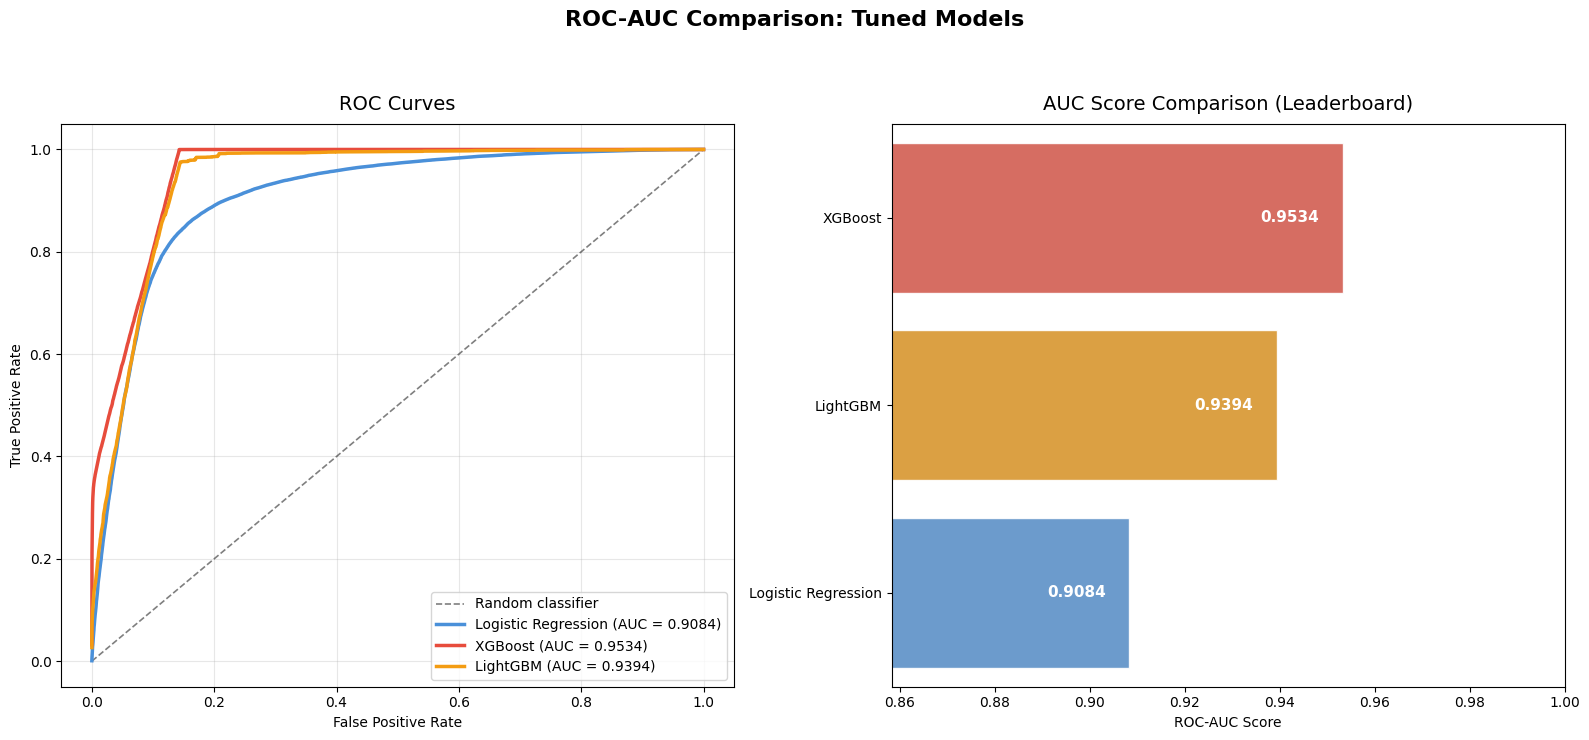


═════════════════════════════════════════════
RANK  MODEL                     TEST AUC  
─────────────────────────────────────────────
1     XGBoost                   0.9534     ⭐
2     LightGBM                  0.9394       
3     Logistic Regression       0.9084       
═════════════════════════════════════════════


In [77]:
COLORS = {
    "Logistic Regression": "#4A90D9",
    "XGBoost": "#E74C3C",
    "LightGBM": "#F39C12",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC-AUC Comparison: Tuned Models", 
             fontsize=16, fontweight="bold", y=1.05)


ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier", alpha=0.5)

rows = []

for name, proba in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    score = auc(fpr, tpr)
    rows.append({"Model": name, "AUC": score})
    
    sns.lineplot(x=fpr, y=tpr, ax=ax, lw=2.5, color=COLORS.get(name, "#333333"),
                 label=f"{name} (AUC = {score:.4f})")

ax.set_title("ROC Curves", fontsize=14, pad=10)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=True)


ax2 = axes[1]
df_aucs = pd.DataFrame(rows).sort_values("AUC", ascending=False)

sns.barplot(data=df_aucs, x='AUC', y='Model', palette=COLORS, 
            ax=ax2, hue='Model', legend=False, alpha=0.9, edgecolor="white")


for i, val in enumerate(df_aucs['AUC']):
    ax2.text(val - 0.005, i, f"{val:.4f}", va='center', ha='right', 
             color='white', fontweight='bold', fontsize=11)

ax2.set_title("AUC Score Comparison (Leaderboard)", fontsize=14, pad=10)


min_auc = df_aucs['AUC'].min()
ax2.set_xlim([max(0, min_auc - 0.05), 1.0])
ax2.set_xlabel("ROC-AUC Score")
ax2.set_ylabel("") 

plt.tight_layout()
plt.show()


print("\n" + "═"*45)
print(f"{'RANK':<5} {'MODEL':<25} {'TEST AUC':<10}")
print("─" * 45)
for i, row in enumerate(df_aucs.itertuples(), 1):
    star = "⭐" if i == 1 else "  "
    print(f"{i:<5} {row.Model:<25} {row.AUC:<10.4f} {star}")
print("═"*45)

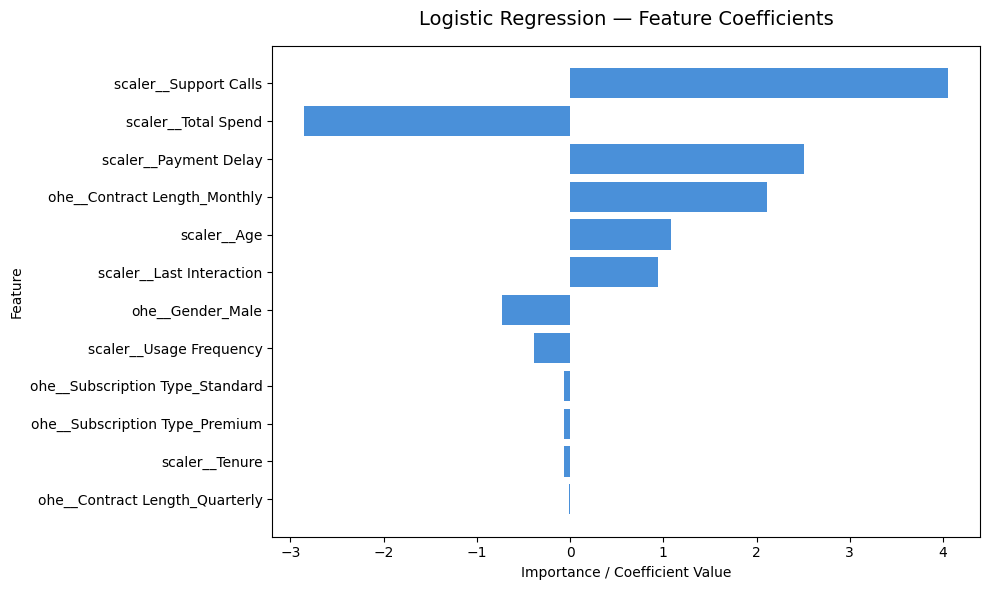

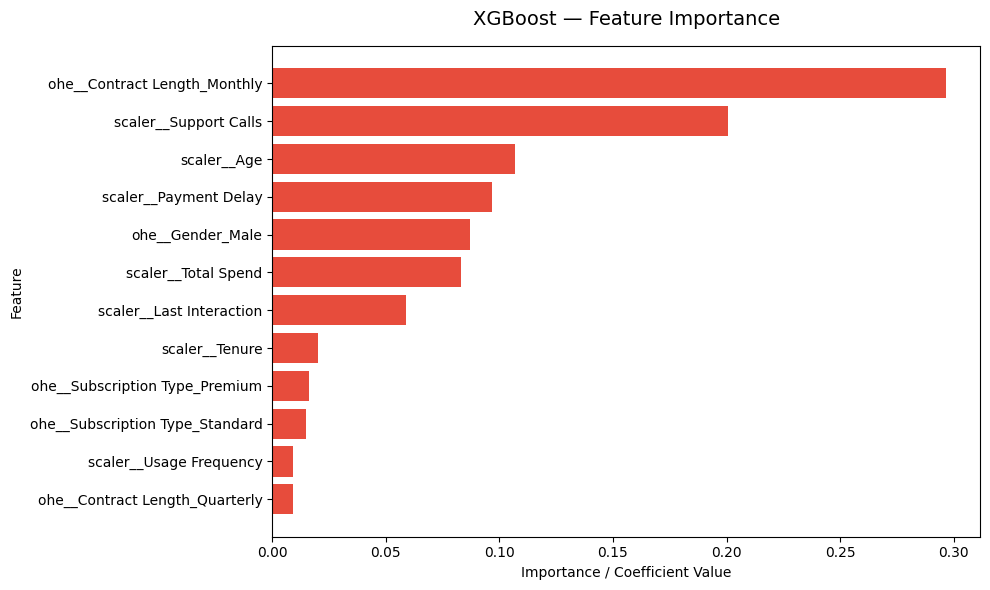

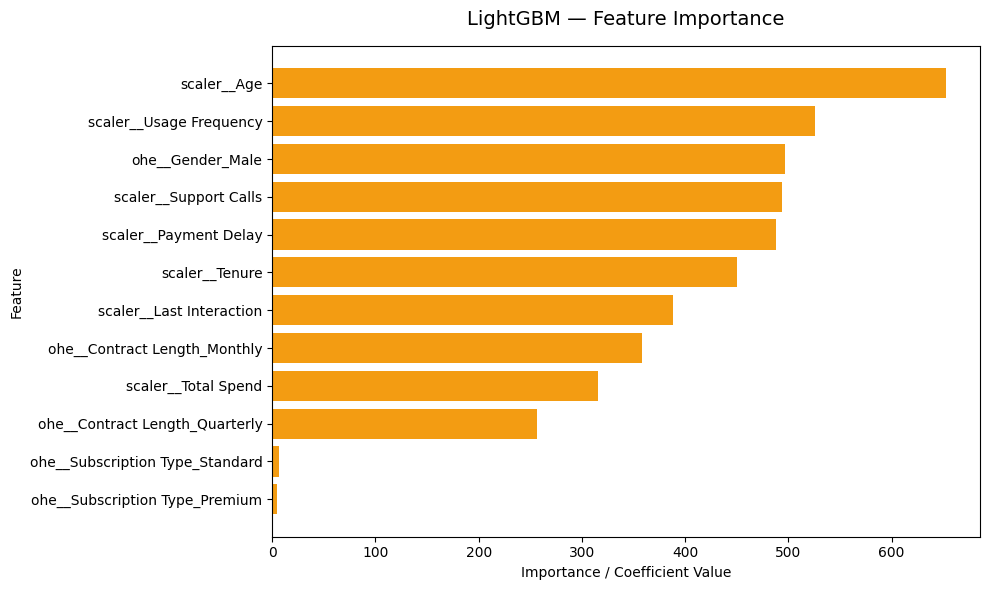

In [78]:

def plot_feature_importance(importances, feature_names, title, color, top_n=20):
    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances})

    df_imp = df_imp.reindex(df_imp["importance"].abs().sort_values(ascending=False).index)
    df_imp = df_imp.head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color=color)
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Importance / Coefficient Value")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()


feature_names = preprocessor.get_feature_names_out().tolist()


plot_feature_importance(
    importances   = lr_best.named_steps['classifier'].coef_[0],
    feature_names = feature_names,
    title         = "Logistic Regression — Feature Coefficients",
    color         = "#4A90D9"
)

plot_feature_importance(
    importances   = xgb_best.named_steps['classifier'].feature_importances_,
    feature_names = feature_names,
    title         = "XGBoost — Feature Importance",
    color         = "#E74C3C"
)

plot_feature_importance(
    importances   = lgbm_best.named_steps['classifier'].feature_importances_,
    feature_names = feature_names,
    title         = "LightGBM — Feature Importance",
    color         = "#F39C12"
)